# 02 · EDA

Exploración de las 5 fuentes crudas de la competencia. Azul = total o clase 0, naranja = clase 1 (aceptó opción de pago).

1. Fuentes y llaves · 2. Variables de train frente a test · 3. Tipos de variables · 4. Etiqueta · 5. Nulos · 6. Duplicados · 7. Numéricas · 8. Categóricas · 9. Outliers · 10. Selección de variables · 11. Hallazgos

In [1]:
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 80, "display.width", 200, "display.float_format", "{:,.2f}".format)

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA = ROOT / "data"

C_BLUE, C_ORANGE, C_GRAY, C_TEXT, C_MUTED = "#2a78d6", "#eb6834", "#c9c8c3", "#0b0b0b", "#52514e"
C_LABEL = {0: C_BLUE, 1: C_ORANGE}
mpl.rcParams.update({
    "figure.dpi": 130, "figure.facecolor": "white", "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": C_GRAY, "axes.grid": True, "grid.color": "#ececea", "grid.linewidth": 0.6, "axes.axisbelow": True,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlelocation": "left", "axes.labelsize": 10,
    "xtick.labelsize": 9, "ytick.labelsize": 9, "text.color": C_TEXT, "axes.labelcolor": C_MUTED,
    "xtick.color": C_MUTED, "ytick.color": C_MUTED,
})
fmt_k = mpl.ticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M" if abs(x) >= 1e6 else (f"{x/1e3:.0f}k" if abs(x) >= 1e3 else f"{x:.0f}"))


def barh_rate(ax, g, title, top=12, sort_by="n"):
    d = pd.DataFrame({"tasa": g.mean(), "n": g.size()})
    d = (d.sort_values("n", ascending=False).head(top) if sort_by == "n" else d.sort_index()).iloc[::-1]
    bars = ax.barh(d.index.astype(str), d.tasa, color=C_ORANGE, height=0.6)
    for b, n, r in zip(bars, d.n, d.tasa):
        ax.text(r + 0.01, b.get_y() + b.get_height() / 2, f"{r:.2f} (n={n:,})", va="center", fontsize=9, color=C_MUTED)
    ax.set_xlim(0, 1.2); ax.set_title(title); ax.grid(axis="y", visible=False)


def barh_freq(ax, s, title, top=10):
    vc = s.fillna("(nulo)").value_counts().head(top).iloc[::-1]
    ax.barh(vc.index.astype(str), vc.values, color=C_BLUE, height=0.6)
    for y, v in zip(vc.index.astype(str), vc.values):
        ax.text(v, y, f" {v/len(s):.1%}", va="center", fontsize=9, color=C_MUTED)
    ax.set_xlim(0, vc.max() * 1.25); ax.set_title(title); ax.grid(axis="y", visible=False); ax.xaxis.set_major_formatter(fmt_k)


def hist(ax, s, title, log=True, bins=60, clip=None):
    s = pd.to_numeric(s, errors="coerce").replace([np.inf, -np.inf], np.nan).dropna()
    if clip is not None: s = s.clip(upper=clip)
    if log: s = np.log10(s[s > 0]); ax.set_xlabel("log10")
    ax.hist(s, bins=bins, color=C_BLUE); ax.set_title(title); ax.yaxis.set_major_formatter(fmt_k)


def box_log(ax, series, title):
    data = [np.log10(pd.to_numeric(s, errors="coerce").replace([np.inf, -np.inf], np.nan).dropna().pipe(lambda x: x[x > 0])) for s in series.values()]
    bp = ax.boxplot(data, labels=list(series), widths=0.5, patch_artist=True,
                    flierprops={"marker": ".", "markersize": 2, "alpha": 0.3, "markeredgecolor": C_ORANGE})
    for p in bp["boxes"]: p.set_facecolor(C_BLUE)
    ax.set_title(title); ax.set_ylabel("log10"); ax.grid(axis="x", visible=False); ax.tick_params(axis="x", rotation=20)

## 1. Fuentes y llaves

Cinco tablas. `nit_enmascarado` identifica al cliente y une con customer; `num_oblig_enmascarado` identifica la obligación y une con probabilidades y pagos. El mes viene como `fecha_var_rpta_alt` (AAAAMM), `fecha_corte` (AAAAMM o AAAAMMDD) y `year`/`month`.

Tabla: filas, columnas, grano, periodo y llave de cada fuente.

In [2]:
tr   = pd.read_csv(DATA / "prueba_op_base_pivot_var_rpta_alt_enmascarado_trtest.csv", low_memory=False)
oot  = pd.read_csv(DATA / "prueba_op_base_pivot_var_rpta_alt_enmascarado_oot.csv")
prob = pd.read_csv(DATA / "prueba_op_probabilidad_oblig_base_hist_enmascarado_completa.csv")
pag  = pd.read_csv(DATA / "prueba_op_maestra_cuotas_pagos_mes_hist_enmascarado_completa.csv", low_memory=False)
cli  = pd.read_csv(DATA / "prueba_op_master_customer_data_enmascarado_completa.csv", low_memory=False)

fuentes = {
    "trtest (train)":  (tr,   "obligación x mes", "2023-08 a 2023-12", ["nit_enmascarado", "num_oblig_orig_enmascarado", "num_oblig_enmascarado", "fecha_var_rpta_alt"]),
    "oot (test)":      (oot,  "obligación",       "2024-01",           ["nit_enmascarado", "num_oblig_orig_enmascarado", "num_oblig_enmascarado"]),
    "probabilidades":  (prob, "obligación x mes", "2023-01 a 2023-12", ["num_oblig_enmascarado", "fecha_corte"]),
    "cuotas y pagos":  (pag,  "obligación x mes", "2023-01 a 2023-12", ["num_oblig_enmascarado", "fecha_corte"]),
    "master customer": (cli,  "cliente x mes",    "2023-07 a 2023-12", ["nit_enmascarado", "year", "month"]),
}
pd.DataFrame([{"fuente": k, "filas": len(df), "columnas": df.shape[1], "grano": g, "periodo": p, "llave": ", ".join(l)}
              for k, (df, g, p, l) in fuentes.items()]).set_index("fuente")

,filas,columnas,grano,periodo,llave
fuente,,,,,
trtest (train),568251,49,obligación x mes,2023-08 a 2023-12,"nit_enmascarado, num_oblig_orig_enmascarado, n..."
oot (test),112549,4,obligación,2024-01,"nit_enmascarado, num_oblig_orig_enmascarado, n..."
probabilidades,4804836,7,obligación x mes,2023-01 a 2023-12,"num_oblig_enmascarado, fecha_corte"
cuotas y pagos,4855035,13,obligación x mes,2023-01 a 2023-12,"num_oblig_enmascarado, fecha_corte"
master customer,430000,37,cliente x mes,2023-07 a 2023-12,"nit_enmascarado, year, month"


Cobertura de llaves: porcentaje de obligaciones de train y test presentes en probabilidades y pagos, y de clientes presentes en customer.

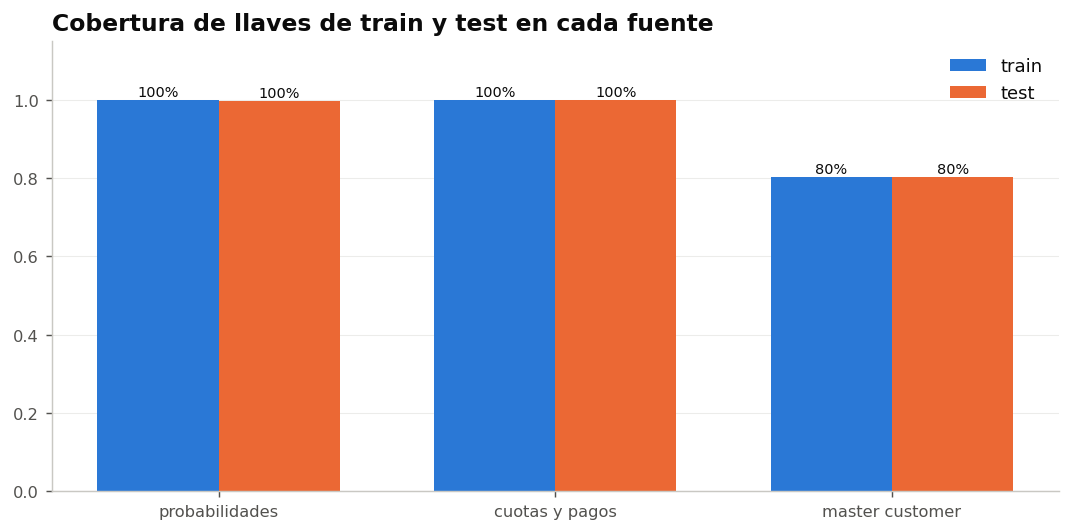

Obligaciones del test que ya aparecen en train: 49%


In [3]:
cob = pd.DataFrame({
    "train": [tr.num_oblig_enmascarado.isin(prob.num_oblig_enmascarado).mean(), tr.num_oblig_enmascarado.isin(pag.num_oblig_enmascarado).mean(), tr.nit_enmascarado.isin(cli.nit_enmascarado).mean()],
    "test":  [oot.num_oblig_enmascarado.isin(prob.num_oblig_enmascarado).mean(), oot.num_oblig_enmascarado.isin(pag.num_oblig_enmascarado).mean(), oot.nit_enmascarado.isin(cli.nit_enmascarado).mean()],
}, index=["probabilidades", "cuotas y pagos", "master customer"])
fig, ax = plt.subplots(figsize=(10, 4.5))
x = np.arange(len(cob)); ax.bar(x - 0.18, cob.train, 0.36, color=C_BLUE, label="train"); ax.bar(x + 0.18, cob.test, 0.36, color=C_ORANGE, label="test")
for i, (a, b) in enumerate(zip(cob.train, cob.test)):
    ax.text(i - 0.18, a + 0.01, f"{a:.0%}", ha="center", fontsize=8); ax.text(i + 0.18, b + 0.01, f"{b:.0%}", ha="center", fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(cob.index); ax.set_ylim(0, 1.15); ax.legend(frameon=False); ax.grid(axis="x", visible=False)
ax.set_title("Cobertura de llaves de train y test en cada fuente"); plt.show()
print(f"Obligaciones del test que ya aparecen en train: {oot.num_oblig_enmascarado.isin(tr.num_oblig_enmascarado).mean():.0%}")

**Lectura.** Probabilidades y pagos cubren más del 99 % de las obligaciones tanto en train como en test; demografía solo el 80 % de los clientes. El test se comporta igual que el train en cobertura, así que las variables construidas desde estas fuentes estarán disponibles para casi todas las filas a calificar. Solo el 49 % de las obligaciones del test tiene historia en train: para la otra mitad no habrá señal de aceptación previa.

## 2. Variables de train frente a test

X_train (trtest) tiene 49 columnas y X_test (oot) solo 4, que son las llaves. El gráfico clasifica las 49 columnas de trtest según si pueden usarse para calificar el test: llaves, etiqueta, descriptores recuperables de otras fuentes, variables solo utilizables como historia rezagada, y variables de resultado del mes que son fuga de información.

X_train: 49 columnas | X_test: 4 columnas ['nit_enmascarado', 'num_oblig_orig_enmascarado', 'num_oblig_enmascarado', 'fecha_var_rpta_alt'] | solo en train: 45


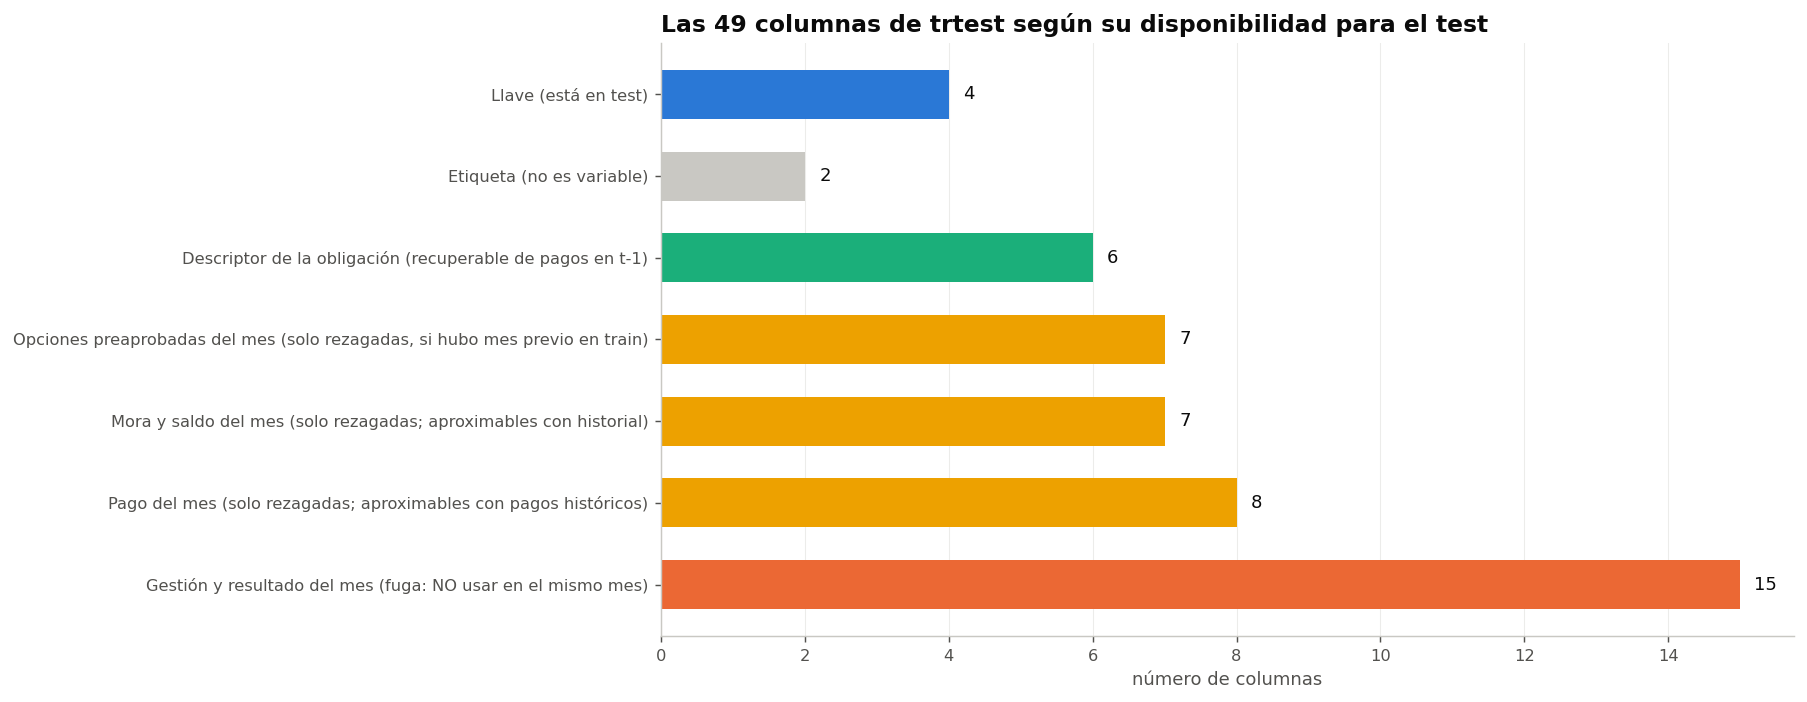

In [4]:
cols_train = list(tr.columns); cols_test = list(oot.columns)
en_ambos = [c for c in cols_train if c in cols_test]; solo_train = [c for c in cols_train if c not in cols_test]
print(f"X_train: {len(cols_train)} columnas | X_test: {len(cols_test)} columnas {cols_test} | solo en train: {len(solo_train)}")

# Clasificación de cada columna de trtest según si podría usarse para el test
GRUPOS = {
    "Llave (está en test)": ["nit_enmascarado", "num_oblig_orig_enmascarado", "num_oblig_enmascarado", "fecha_var_rpta_alt"],
    "Etiqueta (no es variable)": ["var_rpta_alt", "tipo_var_rpta_alt"],
    "Descriptor de la obligación (recuperable de pagos en t-1)": ["banca", "segmento", "producto", "producto_cons", "aplicativo", "vlr_obligacion"],
    "Opciones preaprobadas del mes (solo rezagadas, si hubo mes previo en train)": ["cant_alter_posibles", "desc_alternativa1", "desc_alternativa2", "desc_alternativa3", "alter_posible1_2", "alter_posible2_2", "alter_posible3_2"],
    "Mora y saldo del mes (solo rezagadas; aproximables con historial)": ["min_mora", "max_mora", "dias_mora_fin", "rango_mora", "vlr_vencido", "saldo_capital", "endeudamiento"],
    "Pago del mes (solo rezagadas; aproximables con pagos históricos)": ["valor_cuota_mes", "pago_cuota", "porc_pago_cuota", "pago_mes", "porc_pago_mes", "pagos_tanque", "marca_debito_mora", "marca_pago"],
    "Gestión y resultado del mes (fuga: NO usar en el mismo mes)": ["cant_gestiones", "cant_gestiones_binario", "rpc", "promesas_cumplidas", "cant_promesas_cumplidas_binario", "cant_acuerdo", "cant_acuerdo_binario",
        "descripcion_ranking_mejor_ult", "descripcion_ranking_post_ult", "marca_alt_rank", "marca_alt_apli", "alternativa_aplicada_agr", "marca_agrupada_rgo", "marca_alternativa", "marca_alternativa_orig"],
}
asignadas = sum(GRUPOS.values(), []); faltan = [c for c in cols_train if c not in asignadas]
assert not faltan, faltan
cnt = pd.Series({k: len(v) for k, v in GRUPOS.items()})
colores = [C_BLUE, C_GRAY, "#1baf7a", "#eda100", "#eda100", "#eda100", C_ORANGE]

fig, ax = plt.subplots(figsize=(14, 5.5))
ax.barh(cnt.index[::-1], cnt.values[::-1], color=colores[::-1], height=0.6)
for y, v in zip(cnt.index[::-1], cnt.values[::-1]): ax.text(v + 0.2, y, str(v), va="center", fontsize=10)
ax.set_title(f"Las {len(cols_train)} columnas de trtest según su disponibilidad para el test"); ax.grid(axis="y", visible=False); ax.set_xlabel("número de columnas")
plt.tight_layout(); plt.show()

**Lectura.** Ninguna variable de trtest existe para enero: 6 se recuperan desde pagos en t-1, 22 solo como historia rezagada, y 15 son el resultado del mes (fuga) y no pueden usarse en el mismo mes. Por eso X se construye desde probabilidades, pagos y demografía con corte en t-1, más el historial rezagado de trtest (notebook 01).

## 3. Tipos de variables

Número de columnas de cada fuente por clase. Reglas: identificadores y fechas por nombre; binaria = 2 valores; numérica discreta = numérica con 50 valores o menos; numérica continua = numérica con más de 50; categórica = texto. Debajo, la lista de columnas de trtest por clase.

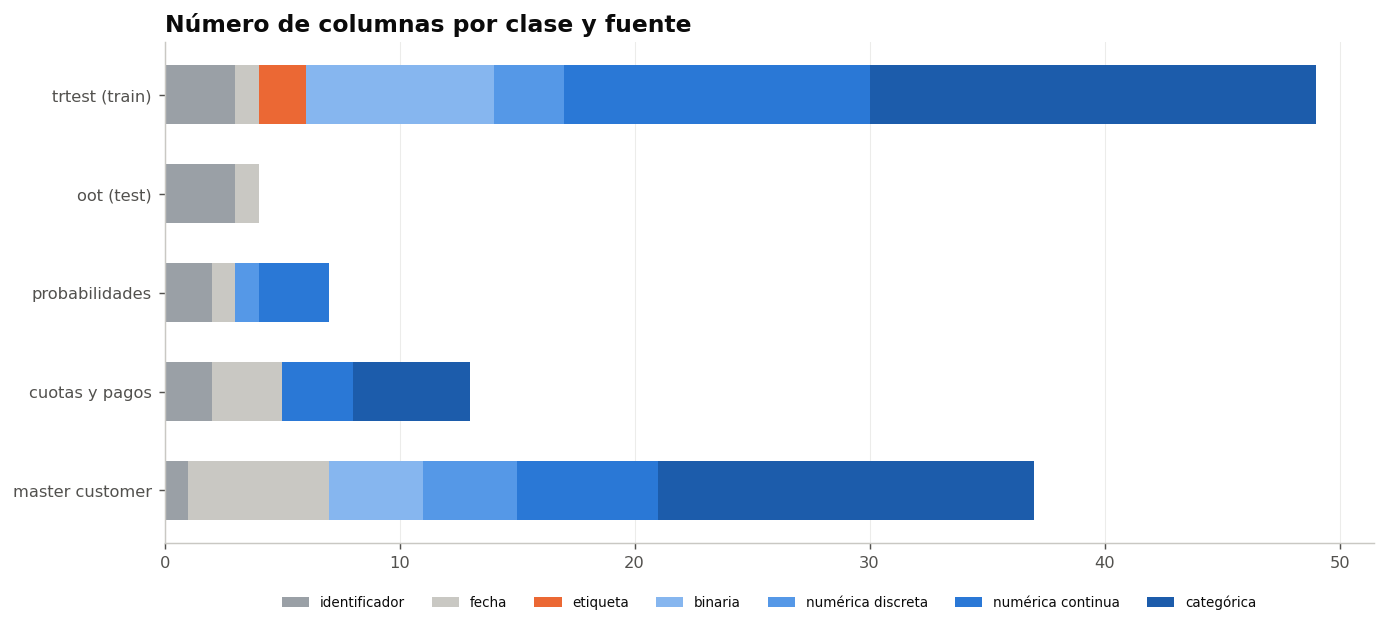

trtest:
  identificador (3): nit_enmascarado, num_oblig_orig_enmascarado, num_oblig_enmascarado
  fecha (1): fecha_var_rpta_alt
  etiqueta (2): var_rpta_alt, tipo_var_rpta_alt
  binaria (8): rango_mora, cant_gestiones_binario, rpc, cant_promesas_cumplidas_binario, cant_acuerdo_binario, marca_alt_apli, pagos_tanque, marca_debito_mora
  numérica discreta (3): cant_alter_posibles, promesas_cumplidas, cant_acuerdo
  numérica continua (13): min_mora, max_mora, dias_mora_fin, vlr_obligacion, vlr_vencido, saldo_capital, endeudamiento, cant_gestiones, valor_cuota_mes, pago_cuota, porc_pago_cuota, pago_mes, porc_pago_mes
  categórica (19): banca, segmento, producto, producto_cons, aplicativo, desc_alternativa1, desc_alternativa2, desc_alternativa3, alter_posible1_2, alter_posible2_2, alter_posible3_2, descripcion_ranking_mejor_ult, descripcion_ranking_post_ult, marca_alt_rank, alternativa_aplicada_agr, marca_agrupada_rgo, marca_pago, marca_alternativa, marca_alternativa_orig


In [5]:
ID_LIKE = {"nit_enmascarado", "num_oblig_enmascarado", "num_oblig_orig_enmascarado"}
DATE_LIKE = {"fecha_var_rpta_alt", "fecha_corte", "year", "month", "ingestion_day", "f_vinc", "f_ult_mantenimiento", "fecha_pago_minima", "fecha_pago_maxima", "ano_nac_cli"}
LABEL = {"var_rpta_alt", "tipo_var_rpta_alt"}

def clase(s, c):
    n = s.nunique()
    if c in ID_LIKE: return "identificador"
    if c in LABEL: return "etiqueta"
    if c in DATE_LIKE: return "fecha"
    if n == 2: return "binaria"
    if pd.api.types.is_numeric_dtype(s): return "numérica continua" if n > 50 else "numérica discreta"
    return "categórica"

tipos = {k: pd.Series({c: clase(df[c], c) for c in df.columns}) for k, (df, *_) in fuentes.items()}
orden = ["identificador", "fecha", "etiqueta", "binaria", "numérica discreta", "numérica continua", "categórica"]
cnt = pd.DataFrame({k: v.value_counts() for k, v in tipos.items()}).reindex(orden).fillna(0).astype(int)

fig, ax = plt.subplots(figsize=(12, 5))
pal = ["#9aa0a6", "#c9c8c3", C_ORANGE, "#86b6ef", "#5598e7", C_BLUE, "#1c5cab"]
left = np.zeros(cnt.shape[1])
for cl, col in zip(orden, pal):
    ax.barh(cnt.columns, cnt.loc[cl], left=left, color=col, label=cl, height=0.6); left += cnt.loc[cl].values
ax.legend(ncol=7, frameon=False, fontsize=7.5, loc="upper center", bbox_to_anchor=(0.5, -0.08)); ax.set_title("Número de columnas por clase y fuente"); ax.grid(axis="y", visible=False); ax.invert_yaxis()
plt.show()

print("trtest:")
for cl in orden:
    cols = tipos["trtest (train)"][tipos["trtest (train)"] == cl].index.tolist()
    if cols: print(f"  {cl} ({len(cols)}): {', '.join(cols)}")

**Lectura.** `trtest` es la tabla ancha (49 columnas, la mayoría categóricas y numéricas continuas) y `oot` solo trae identificadores y fecha: confirma que el test no aporta variables. Probabilidades y pagos son tablas angostas con pocas columnas numéricas; customer es casi toda categórica y con varias fechas. Las categóricas tienen baja cardinalidad, apta para modelos de árboles sin codificación compleja.

## 4. Etiqueta

`var_rpta_alt`: 1 = aceptó opción de pago, 0 = no aceptó. Existe solo en trtest (2023-08 a 2023-12); el test de 2024-01 no la tiene.

Tres paneles: distribución global, filas y tasa de aceptación por mes, y desglose por `tipo_var_rpta_alt` (a, b, c son unos; d, e son ceros).

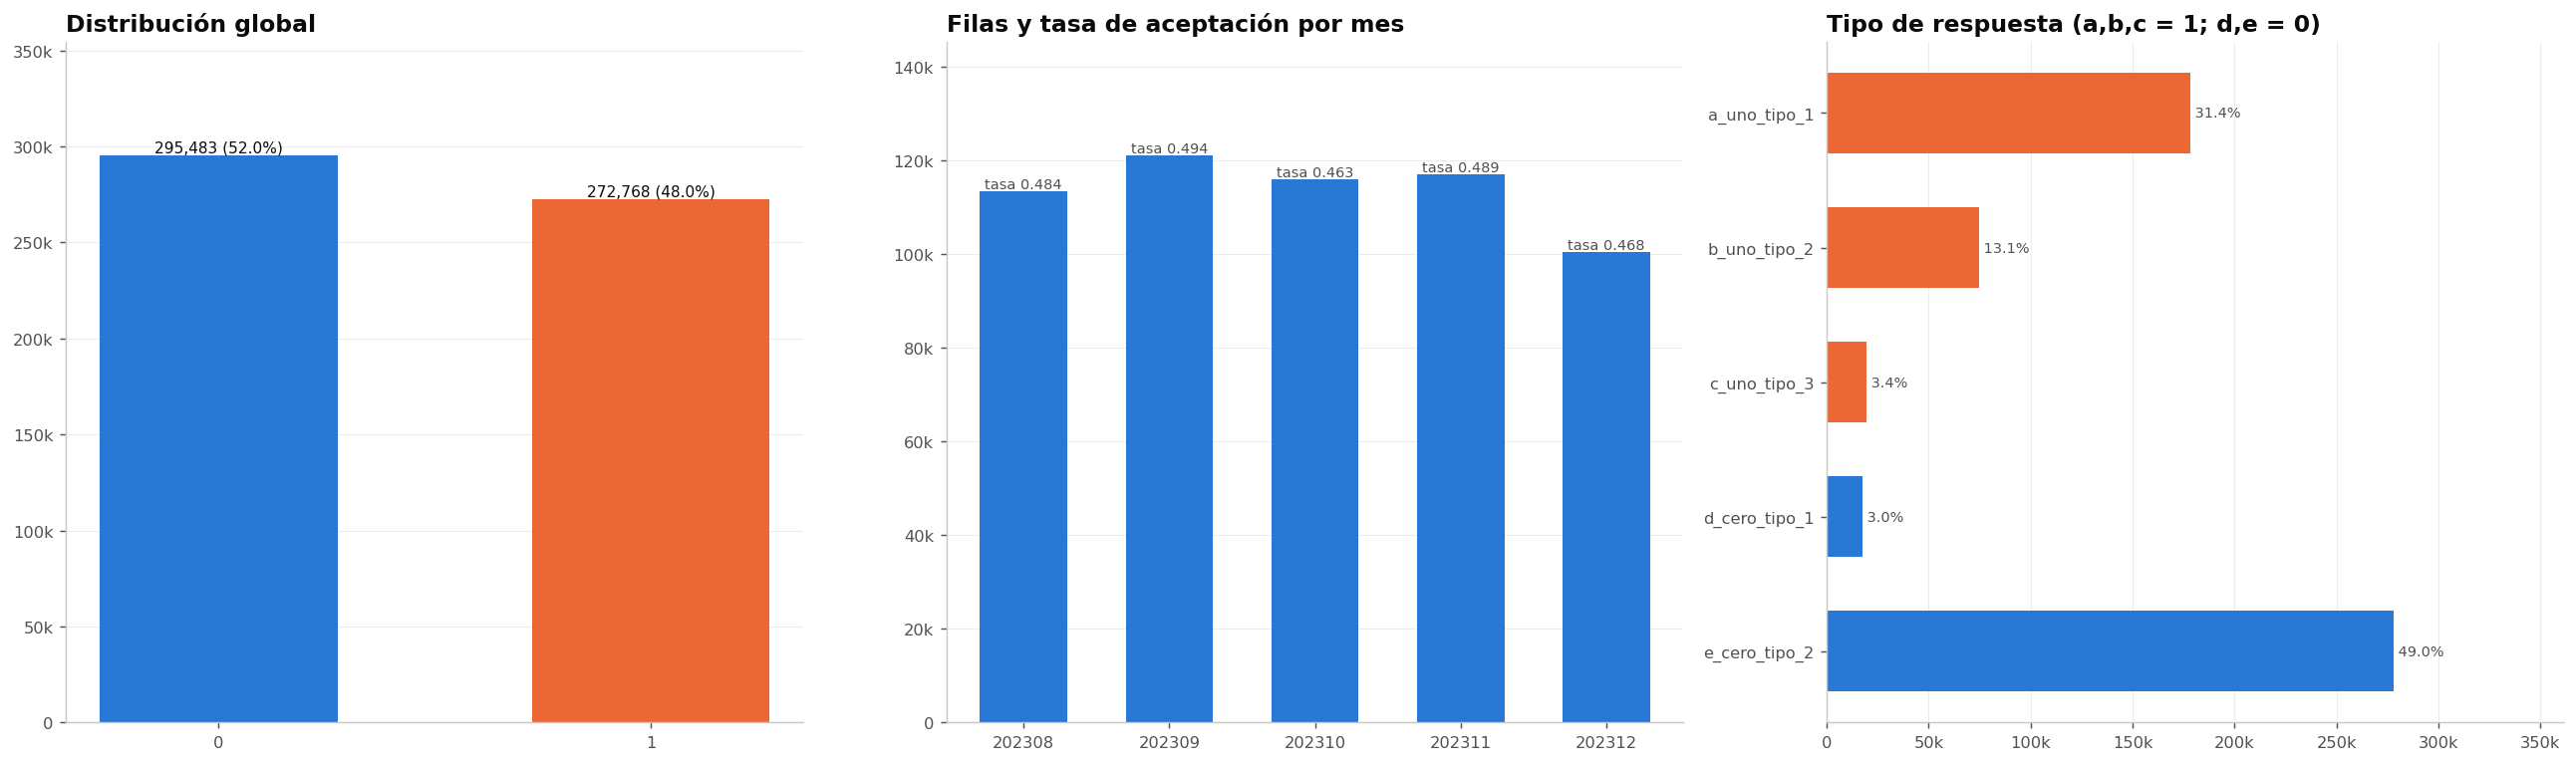

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
vc = tr.var_rpta_alt.value_counts().sort_index()
axes[0].bar(vc.index.astype(str), vc.values, color=[C_LABEL[i] for i in vc.index], width=0.55)
for i, v in zip(vc.index, vc.values): axes[0].text(str(i), v, f"{v:,} ({v/len(tr):.1%})", ha="center", va="bottom", fontsize=8.5)
axes[0].set_title("Distribución global"); axes[0].set_ylim(0, vc.max() * 1.2); axes[0].yaxis.set_major_formatter(fmt_k); axes[0].grid(axis="x", visible=False)

pm = tr.groupby("fecha_var_rpta_alt").var_rpta_alt.agg(["size", "mean"])
axes[1].bar(pm.index.astype(str), pm["size"], color=C_BLUE, width=0.6)
for x, (n, r) in zip(pm.index.astype(str), pm.values): axes[1].text(x, n, f"tasa {r:.3f}", ha="center", va="bottom", fontsize=8, color=C_MUTED)
axes[1].set_title("Filas y tasa de aceptación por mes"); axes[1].set_ylim(0, pm["size"].max() * 1.2); axes[1].yaxis.set_major_formatter(fmt_k); axes[1].grid(axis="x", visible=False)

tv = tr.tipo_var_rpta_alt.value_counts().sort_index()
axes[2].barh(tv.index, tv.values, color=[C_ORANGE if "uno" in t else C_BLUE for t in tv.index], height=0.6)
for y, v in zip(tv.index, tv.values): axes[2].text(v, y, f" {v/len(tr):.1%}", va="center", fontsize=8, color=C_MUTED)
axes[2].set_xlim(0, tv.max() * 1.3); axes[2].set_title("Tipo de respuesta (a,b,c = 1; d,e = 0)"); axes[2].invert_yaxis(); axes[2].xaxis.set_major_formatter(fmt_k); axes[2].grid(axis="y", visible=False)
plt.tight_layout(); plt.show()

**Lectura.** Clases balanceadas (52 % / 48 %): no hace falta rebalanceo y el F1 no estará distorsionado por desbalance. La tasa es estable entre meses (0,46 a 0,49), lo que sugiere que el fenómeno no cambia mucho en el tiempo; diciembre tiene menos filas (100 k). El grupo más grande es `e_cero_tipo_2` (49 %): obligaciones donde no se sabe si se ofreció opción, es decir, gran parte de los ceros no son rechazos sino ausencia de oferta. Entre los unos, el 31 % acepta y se aplica, el 13 % acepta sin aplicación.

Tasa de aceptación por producto, por banca y segmento, por número de opciones preaprobadas y por primera opción preaprobada. Al lado de cada barra, el número de filas.

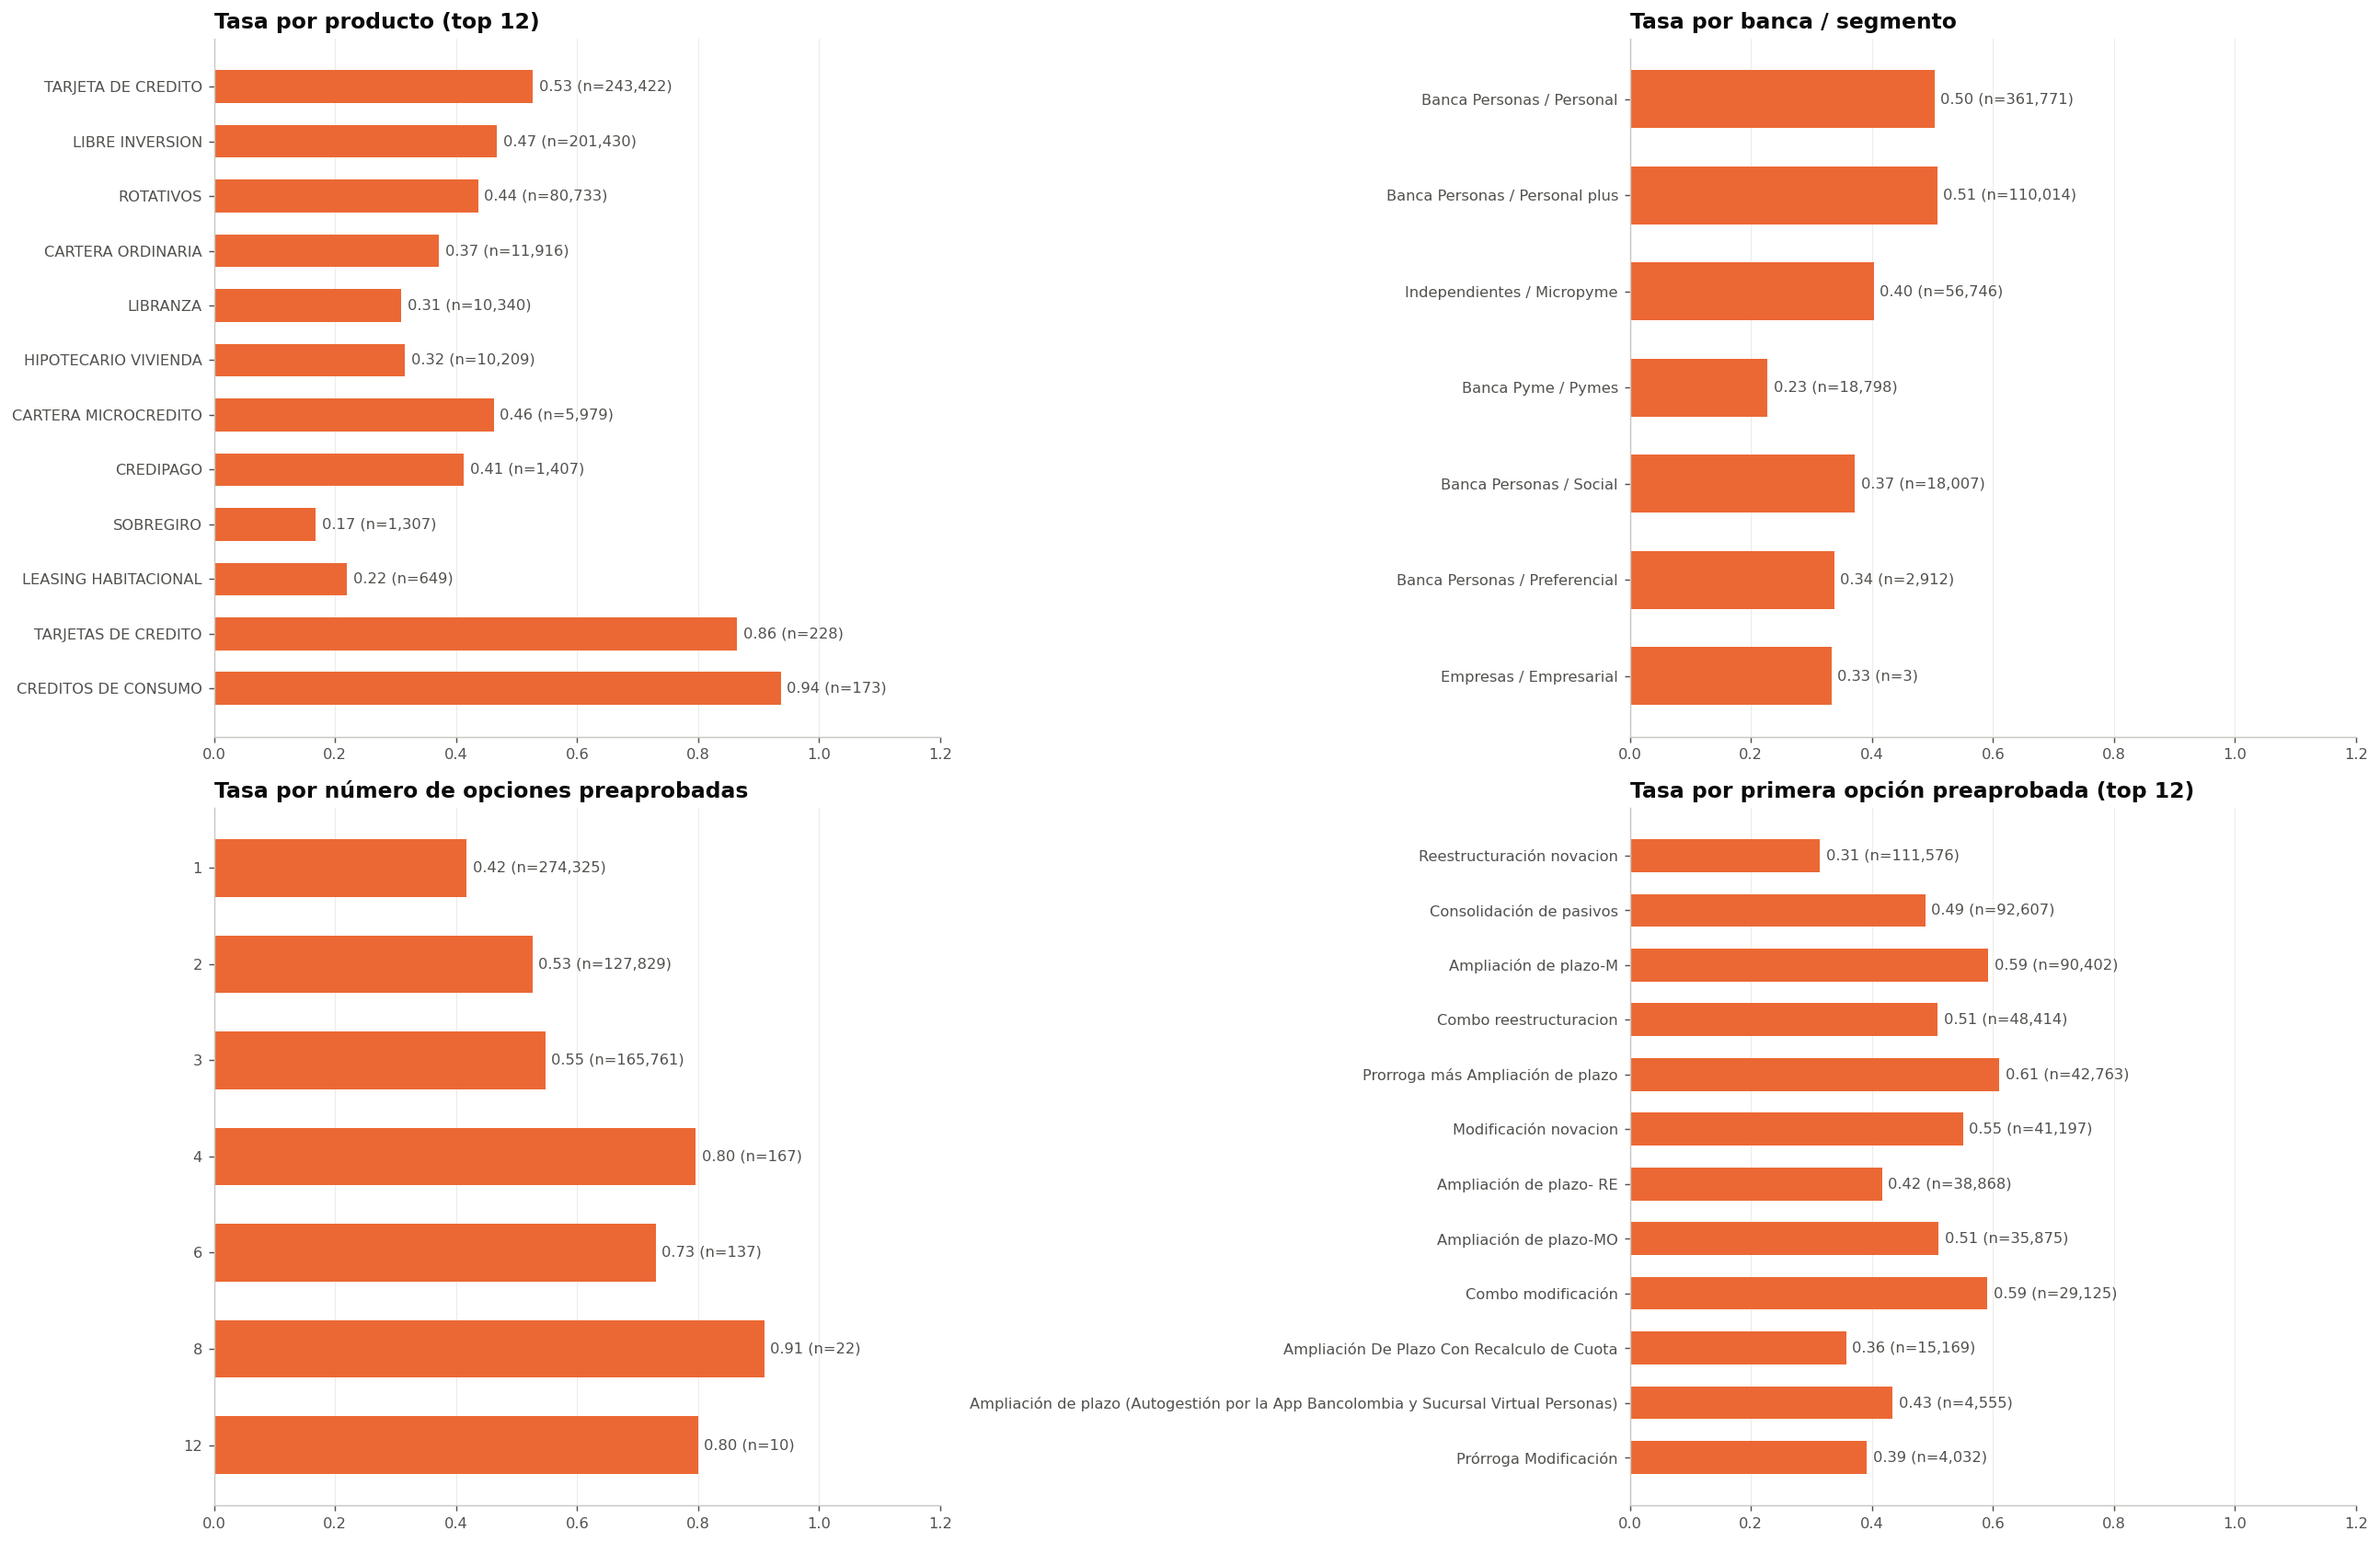

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(20, 13))
barh_rate(axes[0, 0], tr.groupby("producto").var_rpta_alt, "Tasa por producto (top 12)")
barh_rate(axes[0, 1], tr.groupby(tr.banca + " / " + tr.segmento).var_rpta_alt, "Tasa por banca / segmento")
barh_rate(axes[1, 0], tr.groupby("cant_alter_posibles").var_rpta_alt, "Tasa por número de opciones preaprobadas", sort_by="index")
barh_rate(axes[1, 1], tr.groupby("desc_alternativa1").var_rpta_alt, "Tasa por primera opción preaprobada (top 12)")
plt.tight_layout(); plt.show()

**Lectura.** El producto discrimina: tarjeta de crédito 0,53, libre inversión 0,47, rotativos 0,44, hipotecario 0,32, sobregiro 0,17. Las categorías con tasa cercana a 1 tienen muy pocas filas (n < 250) y no son confiables. Por segmento, Banca Personas ronda 0,50 mientras Pymes cae a 0,23 y Social a 0,37. El número de opciones preaprobadas sube la tasa de 0,42 (una) a 0,55 (tres): más alternativas, más aceptación. Por tipo de primera opción, la reestructuración por novación acepta poco (0,31) frente a ampliación de plazo o prórroga (0,59 a 0,61).

Izquierda: tasa de aceptación en el mes t según lo que hizo la misma obligación en t-1. Derecha: número de meses en que aparece cada obligación en trtest.

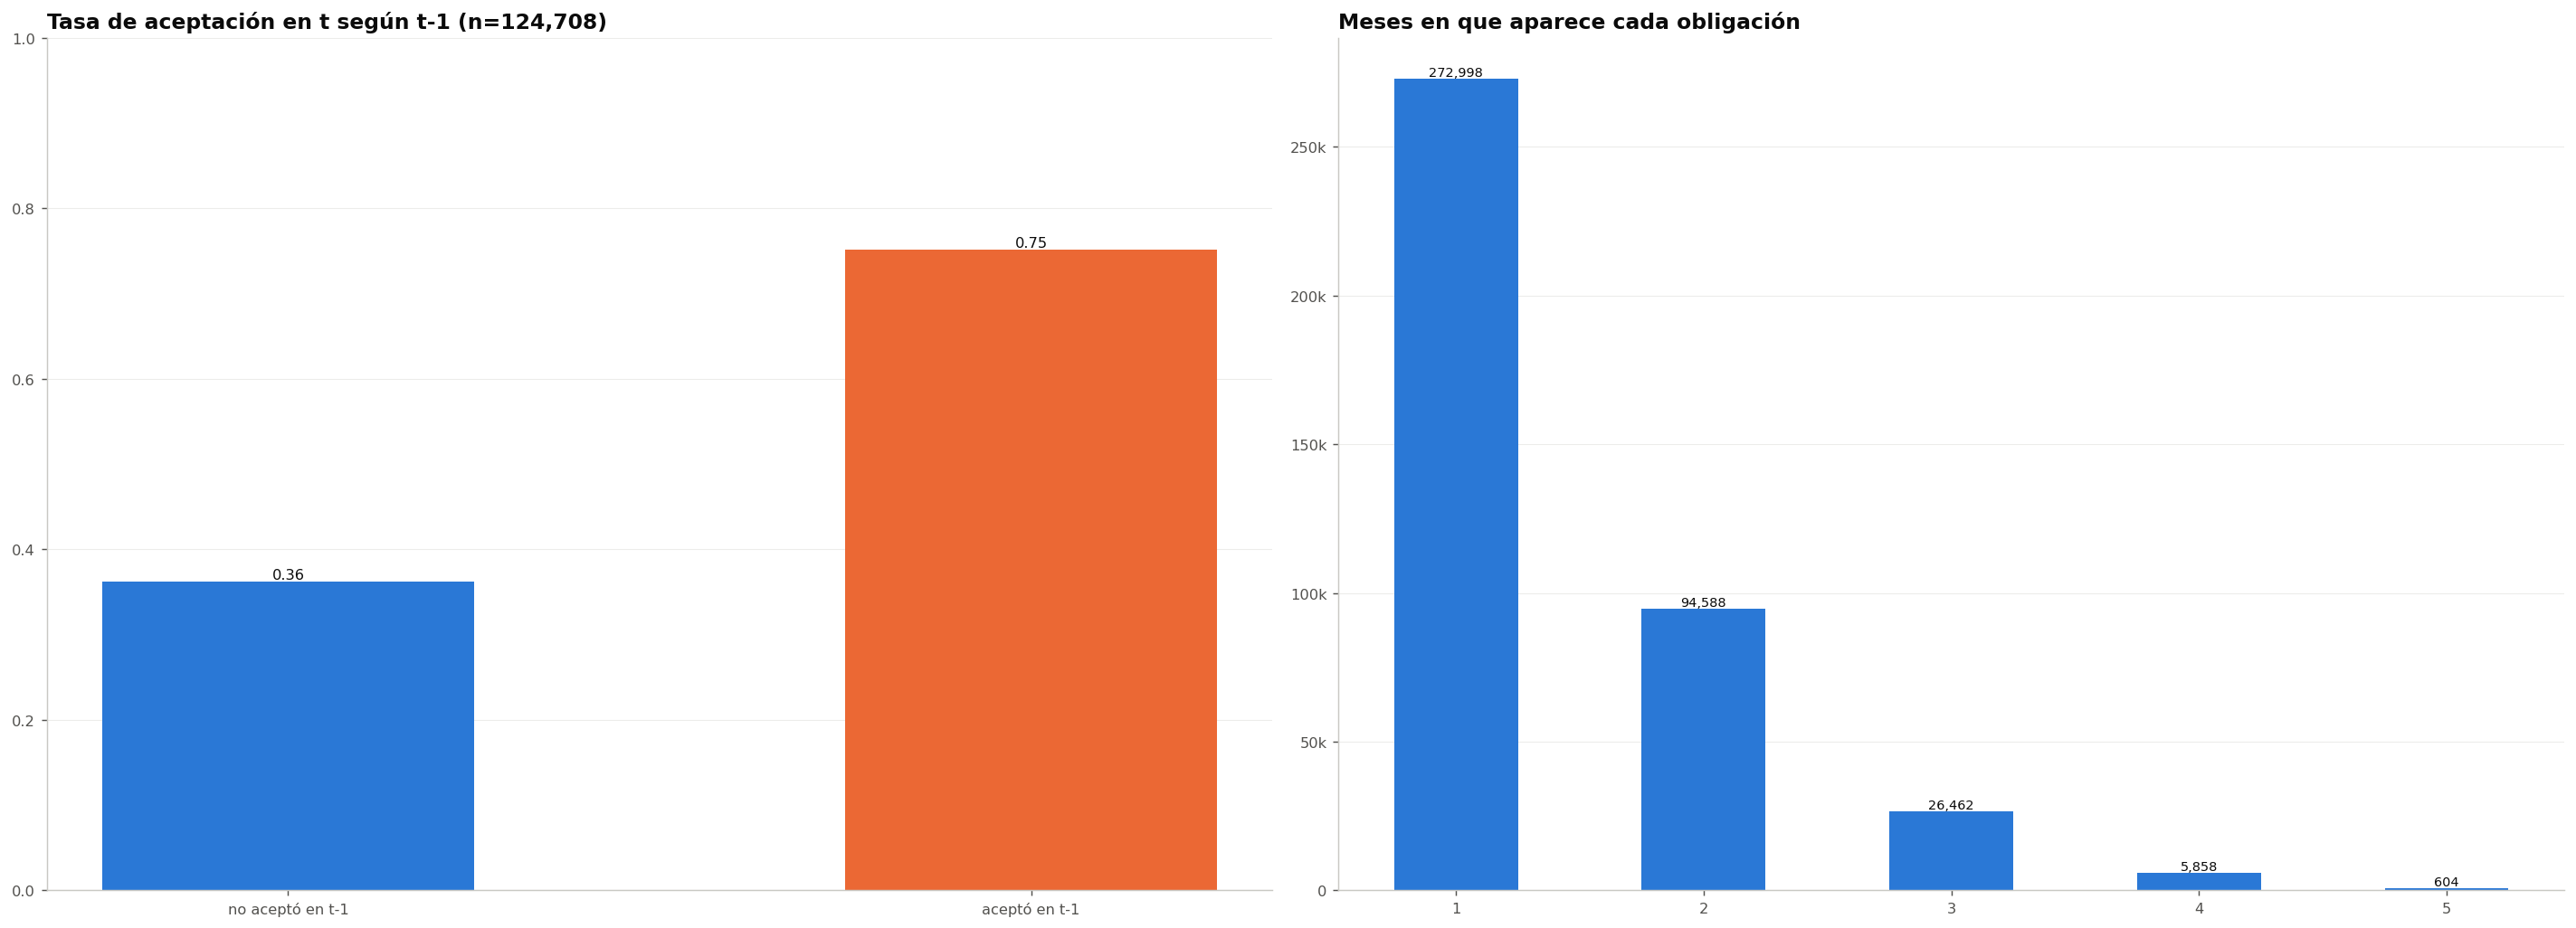

In [8]:
s = tr.sort_values(["num_oblig_enmascarado", "fecha_var_rpta_alt"]).copy()
s["m"] = (s.fecha_var_rpta_alt // 100) * 12 + s.fecha_var_rpta_alt % 100
s["prev"] = s.groupby("num_oblig_enmascarado").var_rpta_alt.shift(); s["prev_m"] = s.groupby("num_oblig_enmascarado").m.shift()
c = s[s.m - s.prev_m == 1]
tasa = c.groupby("prev").var_rpta_alt.mean()

fig, axes = plt.subplots(1, 2, figsize=(22, 8))
axes[0].bar(["no aceptó en t-1", "aceptó en t-1"], tasa.values, color=[C_BLUE, C_ORANGE], width=0.5)
for i, v in enumerate(tasa.values): axes[0].text(i, v, f"{v:.2f}", ha="center", va="bottom", fontsize=9)
axes[0].set_ylim(0, 1); axes[0].set_title(f"Tasa de aceptación en t según t-1 (n={len(c):,})"); axes[0].grid(axis="x", visible=False)
nm = tr.groupby("num_oblig_enmascarado").fecha_var_rpta_alt.nunique().value_counts().sort_index()
axes[1].bar(nm.index.astype(str), nm.values, color=C_BLUE, width=0.5)
for x, v in zip(nm.index.astype(str), nm.values): axes[1].text(x, v, f"{v:,}", ha="center", va="bottom", fontsize=8)
axes[1].set_title("Meses en que aparece cada obligación"); axes[1].yaxis.set_major_formatter(fmt_k); axes[1].grid(axis="x", visible=False)
plt.tight_layout(); plt.show()

**Lectura.** Fuerte persistencia: si la obligación aceptó en t-1, acepta el 65 % en t; si no aceptó, no acepta el 65 %. Es la señal individual más fuerte disponible, pero solo aplica a obligaciones con mes anterior observado. La mayoría de las obligaciones (273 k) aparece un solo mes y 95 k dos meses: la mora es transitoria para la mayoría, y por eso el historial de aceptación estará vacío para muchas filas.

## 5. Nulos

Porcentaje de nulos por columna en trtest, pagos y customer (solo columnas con nulos). El texto `None` del CSV se cuenta como nulo. Probabilidades y test no tienen nulos relevantes.

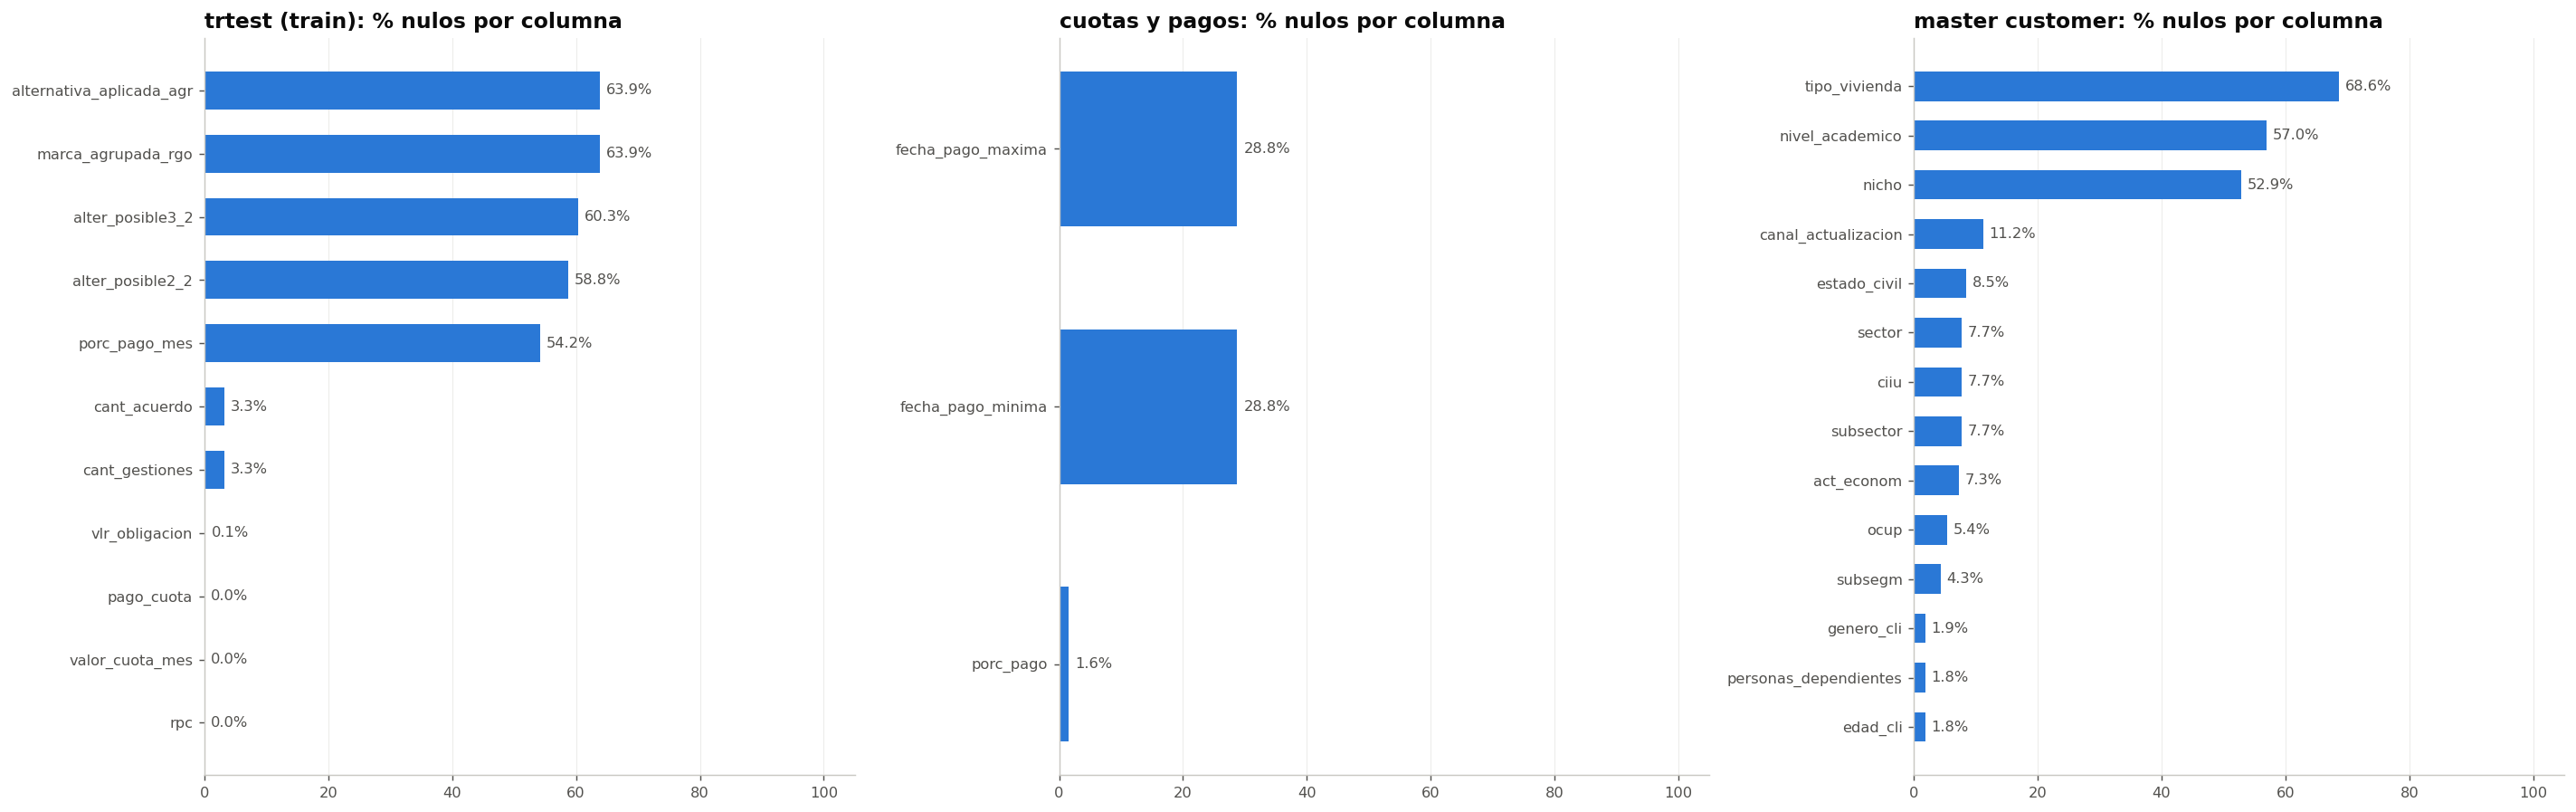

probabilidades: 7 filas con nulos | oot: sin nulos
Nulos estructurales: alter_posible2_2 nulo cuando cant_alter_posibles=1 en 100% de los casos; alternativa_aplicada_agr nulo cuando marca_alt_apli=NO en 93%


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(22, 7))
for ax, k in zip(axes, ["trtest (train)", "cuotas y pagos", "master customer"]):
    p = (fuentes[k][0].isna().mean() * 100); p = p[p > 0].sort_values().tail(14)
    ax.barh(p.index, p.values, color=C_BLUE, height=0.6)
    for y, v in zip(p.index, p.values): ax.text(v + 1, y, f"{v:.1f}%", va="center", fontsize=9, color=C_MUTED)
    ax.set_xlim(0, 105); ax.set_title(f"{k}: % nulos por columna"); ax.grid(axis="y", visible=False)
plt.tight_layout(); plt.show()
print("probabilidades: 7 filas con nulos | oot: sin nulos")
print(f"Nulos estructurales: alter_posible2_2 nulo cuando cant_alter_posibles=1 en {tr[tr.cant_alter_posibles==1].alter_posible2_2.isna().mean():.0%} de los casos; "
      f"alternativa_aplicada_agr nulo cuando marca_alt_apli=NO en {tr[tr.marca_alt_apli=='NO'].alternativa_aplicada_agr.isna().mean():.0%}")

**Lectura.** En `trtest` los nulos son estructurales: alternativa aplicada (64 %) solo existe si se aplicó; opciones 2 y 3 (59 % y 60 %) solo si hay más de una preaprobada; `porc_pago_mes` (54 %) cuando no hubo pago. En pagos, las fechas de pago faltan en el 29 % porque ese mes no hubo pago. En customer sí hay falta real de información: vivienda 69 %, nivel académico 57 %, nicho 53 %; el resto está por debajo del 12 %. Probabilidades y test no tienen nulos relevantes.

## 6. Duplicados

Tabla con filas idénticas y llaves naturales repetidas por fuente, más el detalle de trtest con la llave de 3 campos (nit, obligación, mes).

In [10]:
K3 = ["nit_enmascarado", "num_oblig_enmascarado", "fecha_var_rpta_alt"]
d3 = tr[tr.duplicated(K3, keep=False)]
rows = [{"fuente": k, "filas": len(df), "filas idénticas": int(df.duplicated().sum()), "llaves repetidas": int(df.duplicated(l).sum())} for k, (df, _, _, l) in fuentes.items()]
rows.append({"fuente": "trtest, llave (nit, num_oblig, mes)", "filas": len(tr), "filas idénticas": 0, "llaves repetidas": int(tr.duplicated(K3).sum())})
display(pd.DataFrame(rows).set_index("fuente"))
print(f"Los {len(d3)} repetidos de trtest por (nit, num_oblig, mes) son la misma obligación con dos num_oblig_orig distintos, "
      f"misma etiqueta en el {1 - d3.groupby(K3).var_rpta_alt.nunique().gt(1).mean():.0%} de los grupos. IDs de entrega distintos: se conservan.")

,filas,filas idénticas,llaves repetidas
fuente,,,
trtest (train),568251,0,0
oot (test),112549,0,0
probabilidades,4804836,0,3
cuotas y pagos,4855035,0,28
master customer,430000,0,1
"trtest, llave (nit, num_oblig, mes)",568251,0,238


Los 475 repetidos de trtest por (nit, num_oblig, mes) son la misma obligación con dos num_oblig_orig distintos, misma etiqueta en el 100% de los grupos. IDs de entrega distintos: se conservan.


**Lectura.** No hay filas idénticas en ninguna tabla. Las llaves repetidas de las auxiliares son mínimas (3, 28 y 1). Los 475 repetidos de `trtest` por (nit, obligación, mes) son la misma obligación con dos números de obligación original, con la misma etiqueta; como el ID de entrega incluye ese número, son filas distintas y se conservan.

## 7. Variables numéricas

Histogramas de trtest (montos en log10, días de mora, gestiones, porcentaje de pago de la cuota), de los tres scores de probabilidades y del porcentaje de pago en pagos.

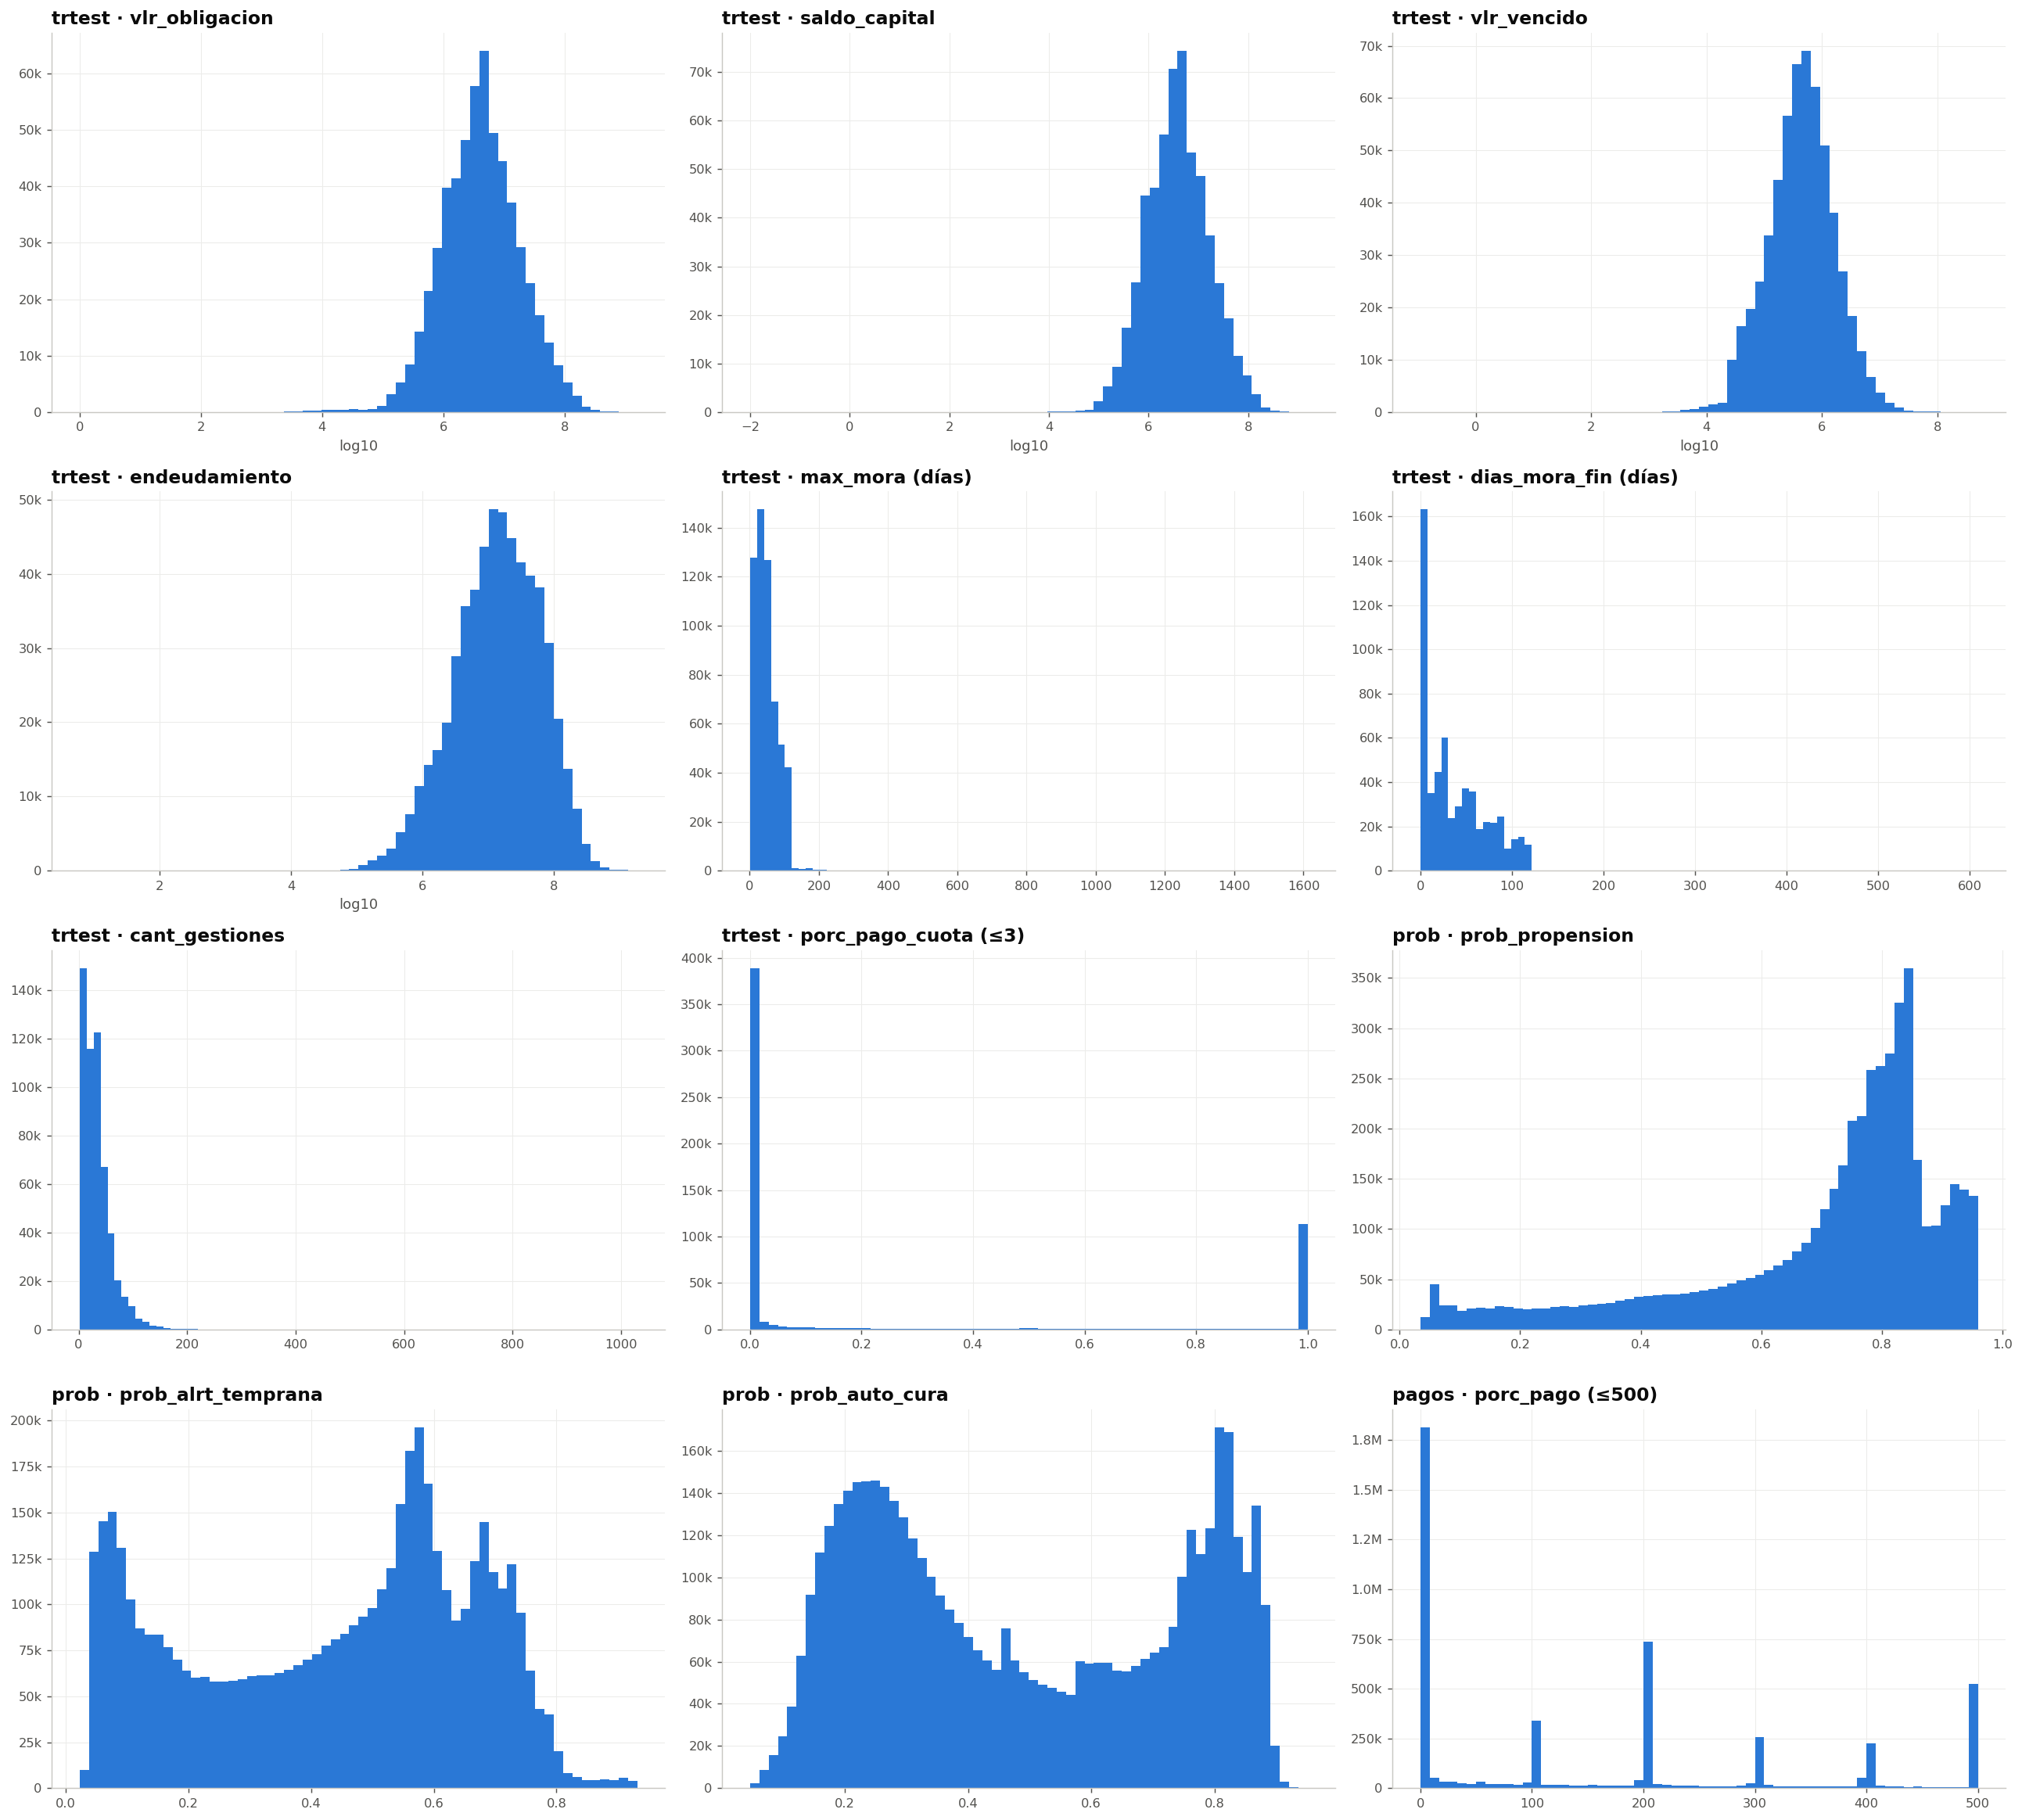

In [11]:
fig, ax = plt.subplots(4, 3, figsize=(20, 18)); ax = ax.ravel()
hist(ax[0], tr.vlr_obligacion, "trtest · vlr_obligacion"); hist(ax[1], tr.saldo_capital, "trtest · saldo_capital")
hist(ax[2], tr.vlr_vencido, "trtest · vlr_vencido"); hist(ax[3], tr.endeudamiento, "trtest · endeudamiento")
hist(ax[4], tr.max_mora, "trtest · max_mora (días)", log=False, bins=80); hist(ax[5], tr.dias_mora_fin, "trtest · dias_mora_fin (días)", log=False, bins=80)
hist(ax[6], tr.cant_gestiones, "trtest · cant_gestiones", log=False, bins=80); hist(ax[7], tr.porc_pago_cuota, "trtest · porc_pago_cuota (≤3)", log=False, clip=3)
hist(ax[8], prob.prob_propension, "prob · prob_propension", log=False); hist(ax[9], prob.prob_alrt_temprana, "prob · prob_alrt_temprana", log=False)
hist(ax[10], prob.prob_auto_cura, "prob · prob_auto_cura", log=False); hist(ax[11], pag.porc_pago, "pagos · porc_pago (≤500)", log=False, clip=500)
plt.tight_layout(); plt.show()

**Lectura.** Los montos (obligación, saldo, vencido, endeudamiento) son lognormales, centrados entre 10^6 y 10^7 pesos, con colas a ambos lados. `max_mora` se concentra por debajo de 120 días (99 % de las filas) con una cola hasta 1.600. `dias_mora_fin` tiene un pico en 0 (159 k filas): muchas obligaciones se ponen al día antes de fin de mes. `cant_gestiones` es asimétrica con moda entre 20 y 40 contactos y cola hasta 1.000. `porc_pago_cuota` es bimodal: 62 % no paga nada y 19 % paga la cuota completa. Los scores del banco no son uniformes: propensión se acumula en valores altos (moda 0,85), alerta temprana y autocura son bimodales, lo que indica dos poblaciones claras. `porc_pago` en pagos se agrupa en múltiplos de 100 % (72 % de los casos): los clientes pagan cuotas enteras.

Histogramas de cuota y pago total en pagos (log10) y de edad, ingresos, activos, pasivos, egresos y patrimonio en customer (log10).

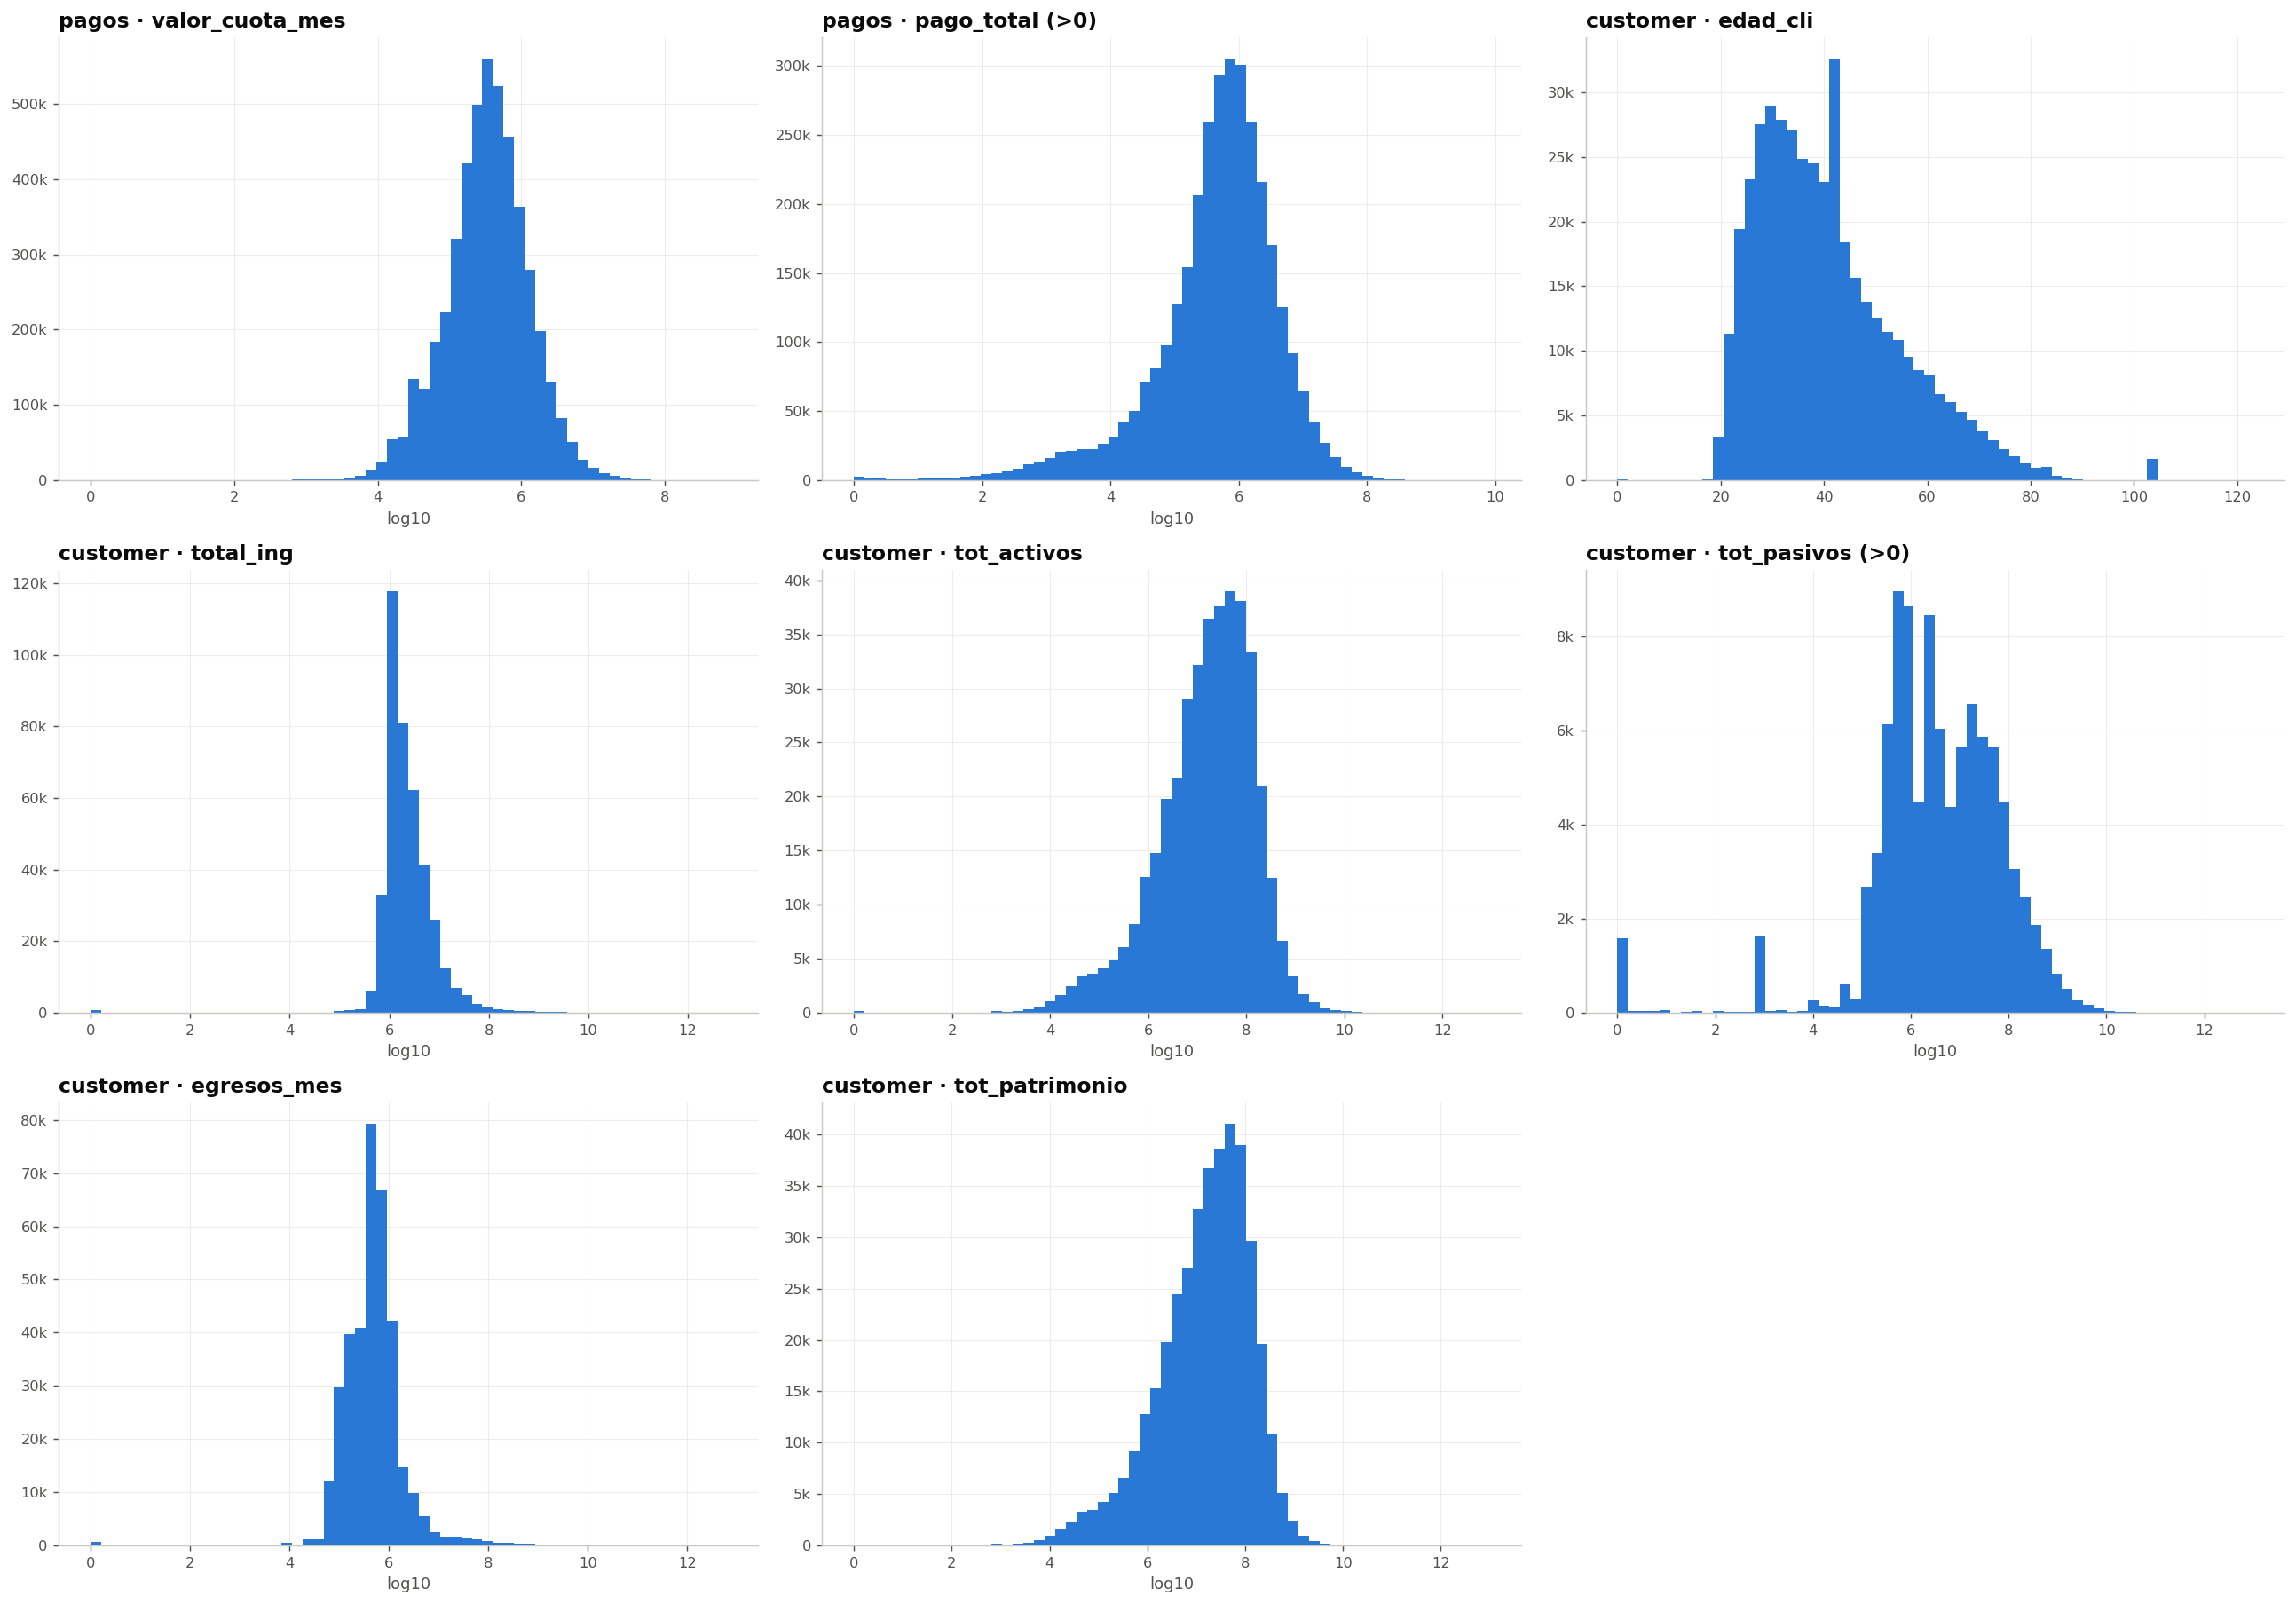

In [12]:
fig, ax = plt.subplots(3, 3, figsize=(20, 14)); ax = ax.ravel()
ax[8].axis("off")
hist(ax[0], pag.valor_cuota_mes, "pagos · valor_cuota_mes"); hist(ax[1], pag.pago_total, "pagos · pago_total (>0)")
hist(ax[2], cli.edad_cli, "customer · edad_cli", log=False); hist(ax[3], cli.total_ing, "customer · total_ing")
hist(ax[4], cli.tot_activos, "customer · tot_activos"); hist(ax[5], cli.tot_pasivos, "customer · tot_pasivos (>0)")
hist(ax[6], cli.egresos_mes, "customer · egresos_mes"); hist(ax[7], cli.tot_patrimonio, "customer · tot_patrimonio")
plt.tight_layout(); plt.show()

**Lectura.** Cuota y pago total son lognormales (cuota mediana 340 k, pago mediano 610 k cuando hay pago; el 33 % de los meses no tiene pago). La edad tiene moda en 30 y mediana en 38, con el 50 % entre 30 y 49 años. Ingresos con mediana de 1,7 M y cola larga. Activos y patrimonio tienen distribución amplia; pasivos es 0 en el 77 % de los clientes y egresos 0 en el 17 %, así que estas variables deben leerse como "reportado o no" además de su magnitud.

Distribución por clase de cuatro variables de trtest medidas en el mismo mes de la etiqueta: días de mora a fin de mes, gestiones, saldo y endeudamiento (estos dos en log10).

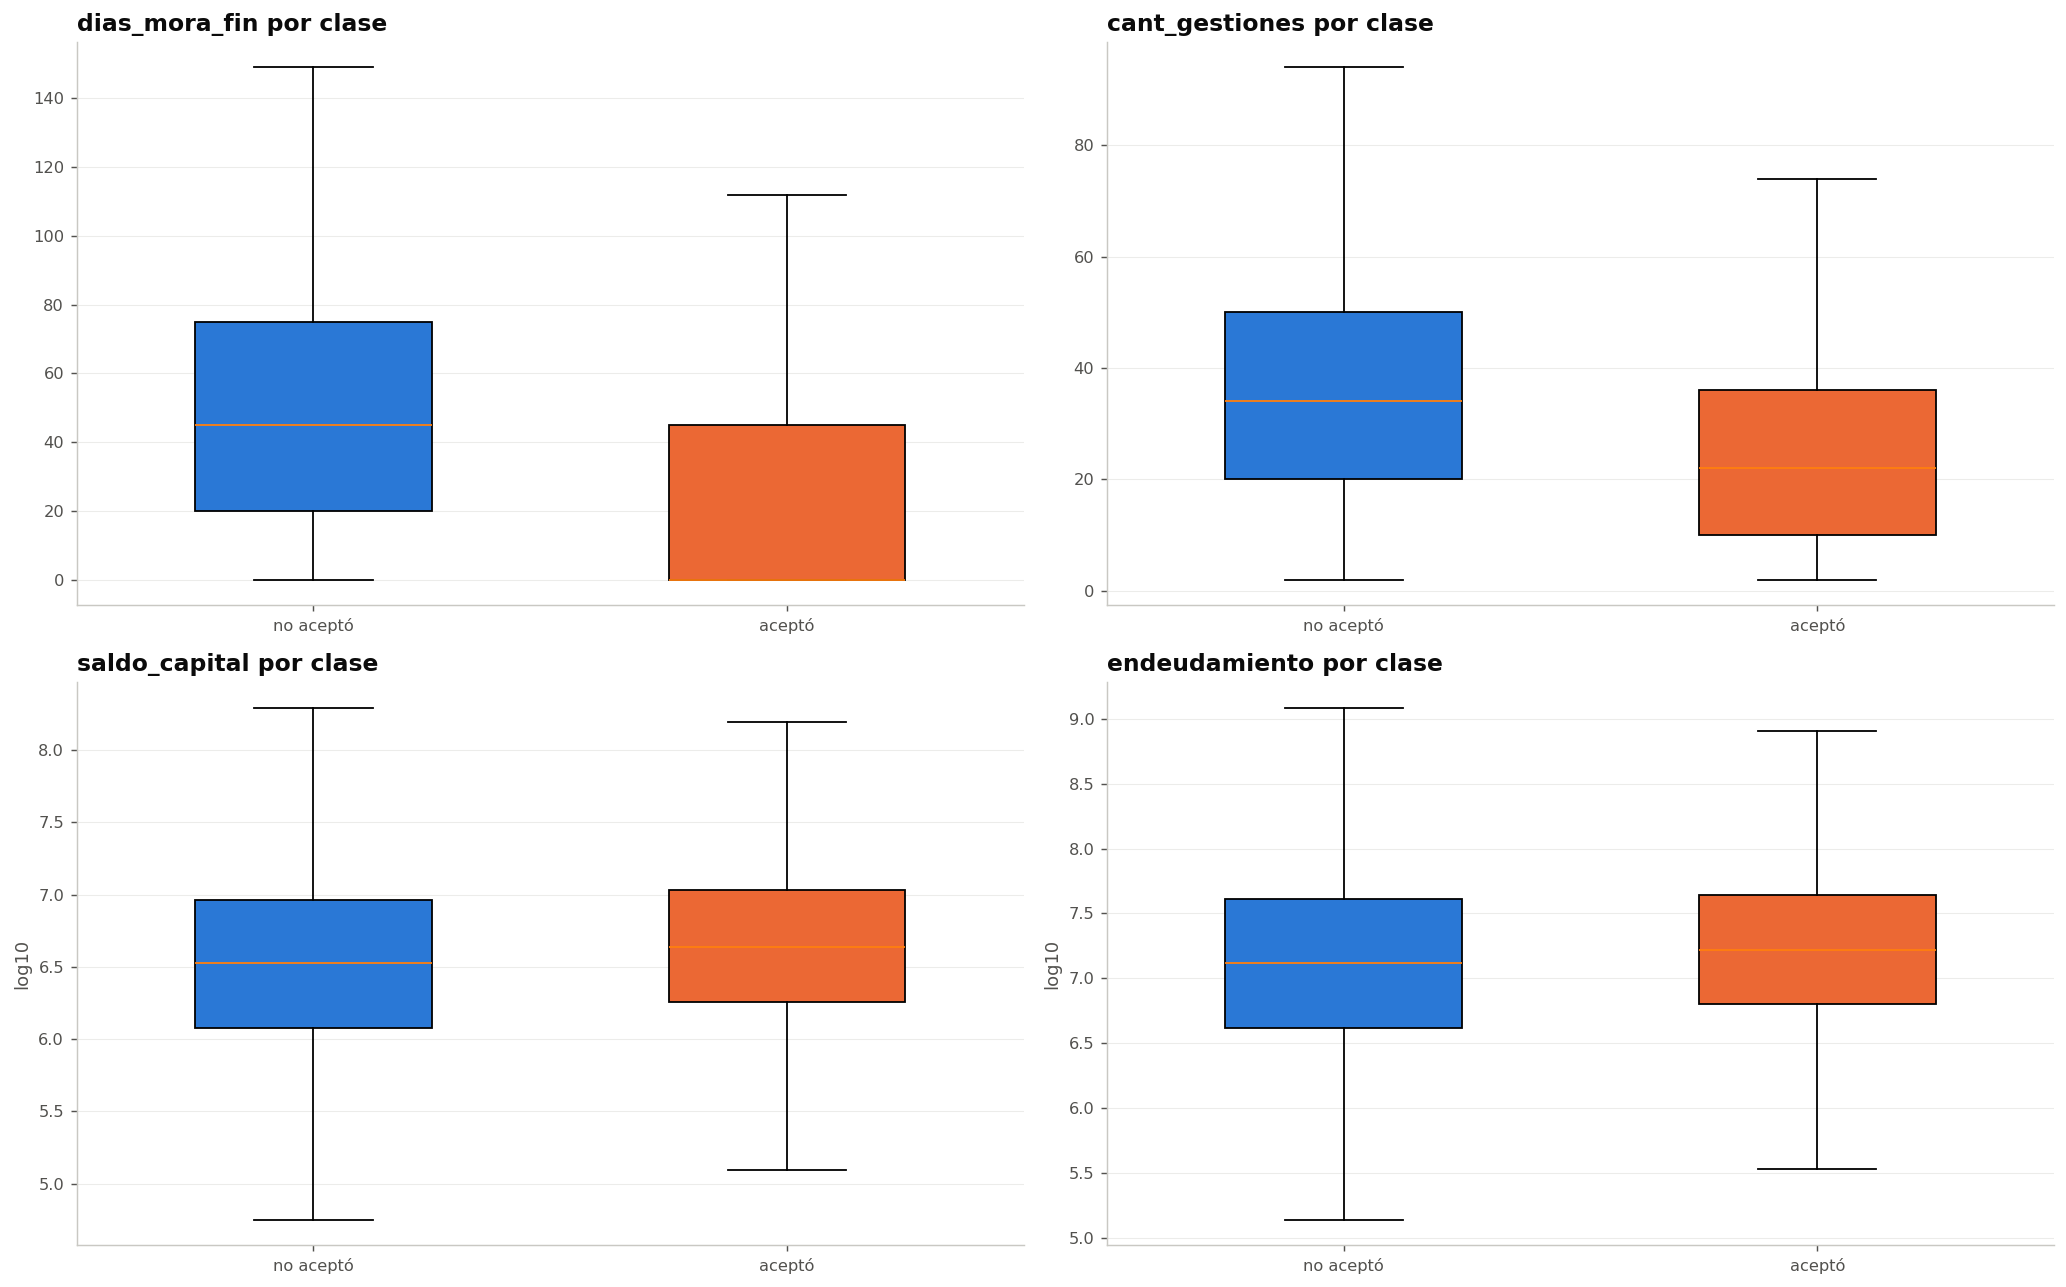

In [13]:
# Por clase. Ojo: estas variables se miden en el mismo mes de la etiqueta (describen el resultado, no lo anticipan).
fig, axes = plt.subplots(2, 2, figsize=(16, 10)); axes = axes.ravel()
for ax, c in zip(axes, ["dias_mora_fin", "cant_gestiones", "saldo_capital", "endeudamiento"]):
    data = [tr.loc[tr.var_rpta_alt == k, c].dropna() for k in (0, 1)]
    if c in ("saldo_capital", "endeudamiento"): data = [np.log10(d[d > 0]) for d in data]; ax.set_ylabel("log10")
    bp = ax.boxplot(data, labels=["no aceptó", "aceptó"], widths=0.5, patch_artist=True, showfliers=False)
    for p, k in zip(bp["boxes"], (0, 1)): p.set_facecolor(C_LABEL[k])
    ax.set_title(f"{c} por clase"); ax.grid(axis="x", visible=False)
plt.tight_layout(); plt.show()

**Lectura.** Quien acepta termina el mes al día (mediana de `dias_mora_fin` 0 frente a 45) y recibe menos gestiones (mediana 22 frente a 34): la aceptación resuelve la mora y detiene la gestión. Saldo y endeudamiento son algo mayores en quienes aceptan (medianas 4,2 M frente a 3,3 M y 16,4 M frente a 13,2 M): a mayor deuda, más incentivo a aliviar la carga. Estas variables se miden en el mismo mes de la etiqueta, así que describen la consecuencia, no la causa; en el modelo solo entran rezagadas.

## 8. Variables categóricas

Tasa de aceptación por categoría en seis columnas de trtest: rango de mora, aplicativo, primera opción codificada, ranking de gestión, marca de pago y marca de alternativa. Máximo 37 valores distintos por columna.

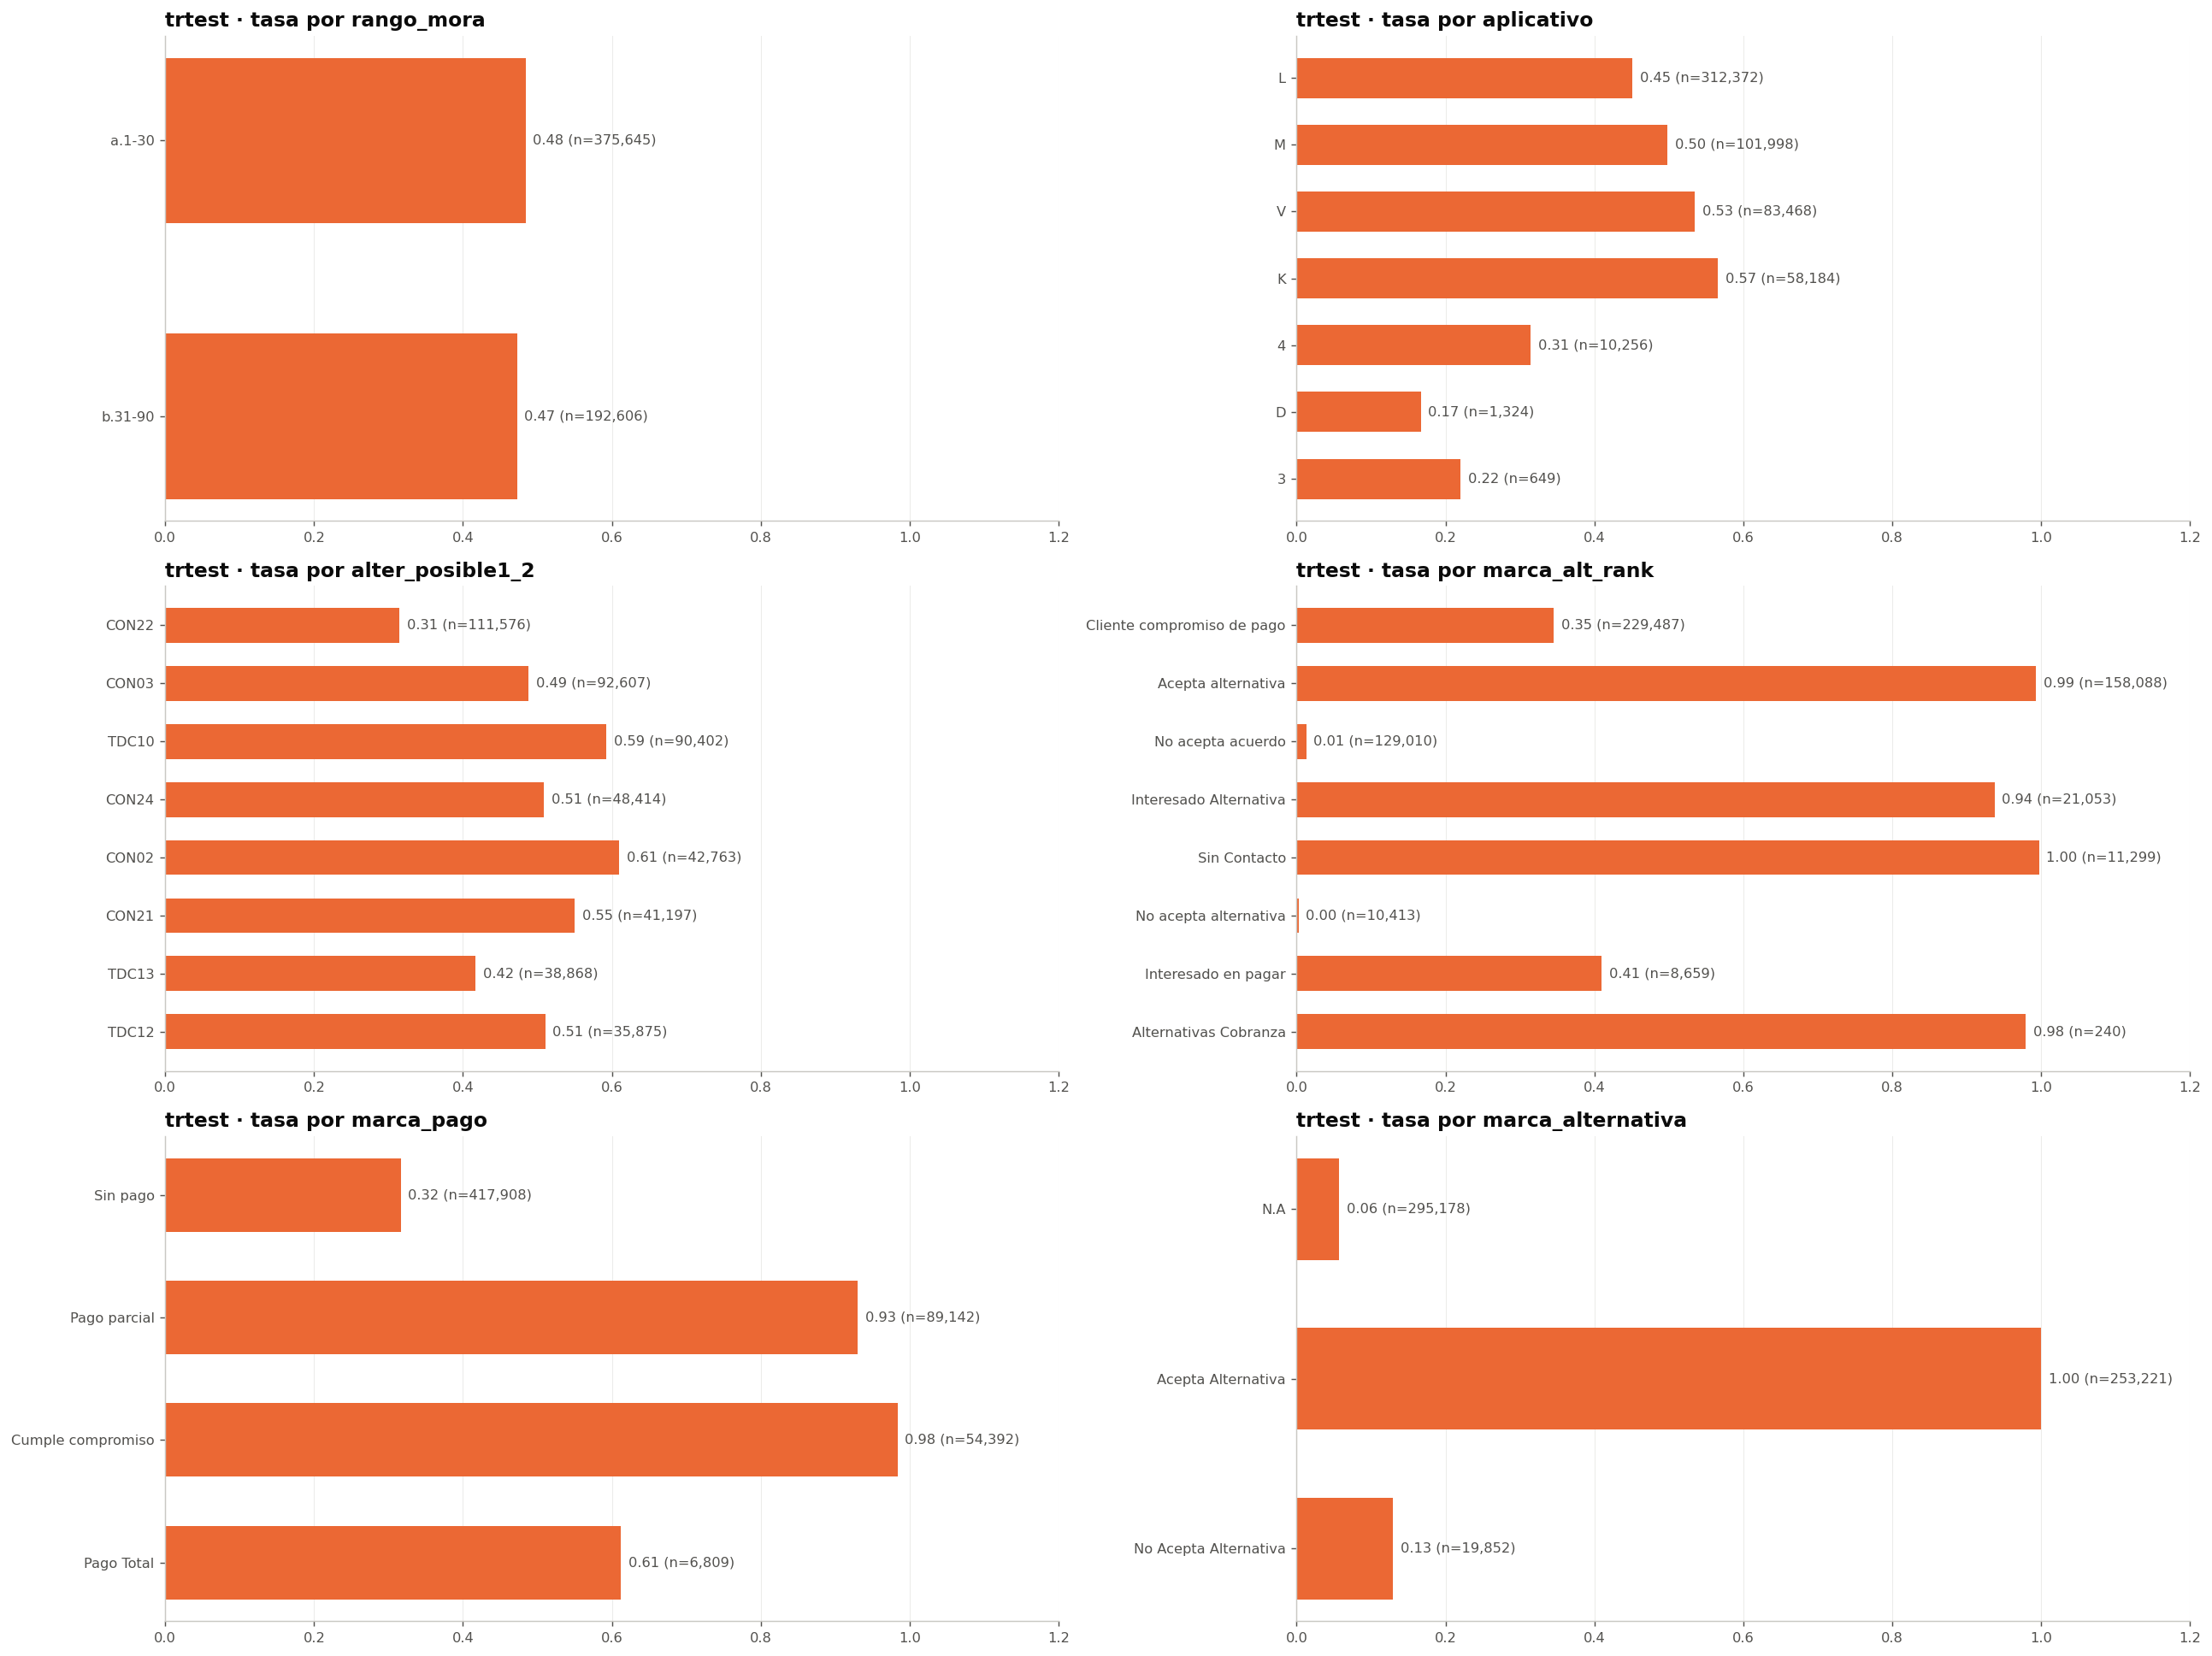

In [14]:
fig, ax = plt.subplots(3, 2, figsize=(20, 15)); ax = ax.ravel()
for a, c in zip(ax, ["rango_mora", "aplicativo", "alter_posible1_2", "marca_alt_rank", "marca_pago", "marca_alternativa"]):
    barh_rate(a, tr.groupby(c).var_rpta_alt, f"trtest · tasa por {c}", top=8)
plt.tight_layout(); plt.show()

**Lectura.** `rango_mora` no discrimina (0,48 frente a 0,47). El aplicativo sí: K 0,57, V 0,53, M 0,50, L 0,45 y los aplicativos 3, 4 y D por debajo de 0,31. La primera opción codificada va de 0,31 (CON22, reestructuración) a 0,61 (CON02, prórroga). `marca_alt_rank`, `marca_pago` y `marca_alternativa` separan casi perfectamente las clases (tasas de 0,00 a 1,00): son el resultado de la gestión del mes, es decir, fuga de información. No pueden usarse como variables del mismo mes.

Frecuencia de las categorías principales en pagos (marca de pago, ajustes del banco, producto) y en customer (ocupación, estado civil, nivel académico). Los nulos aparecen como (nulo).

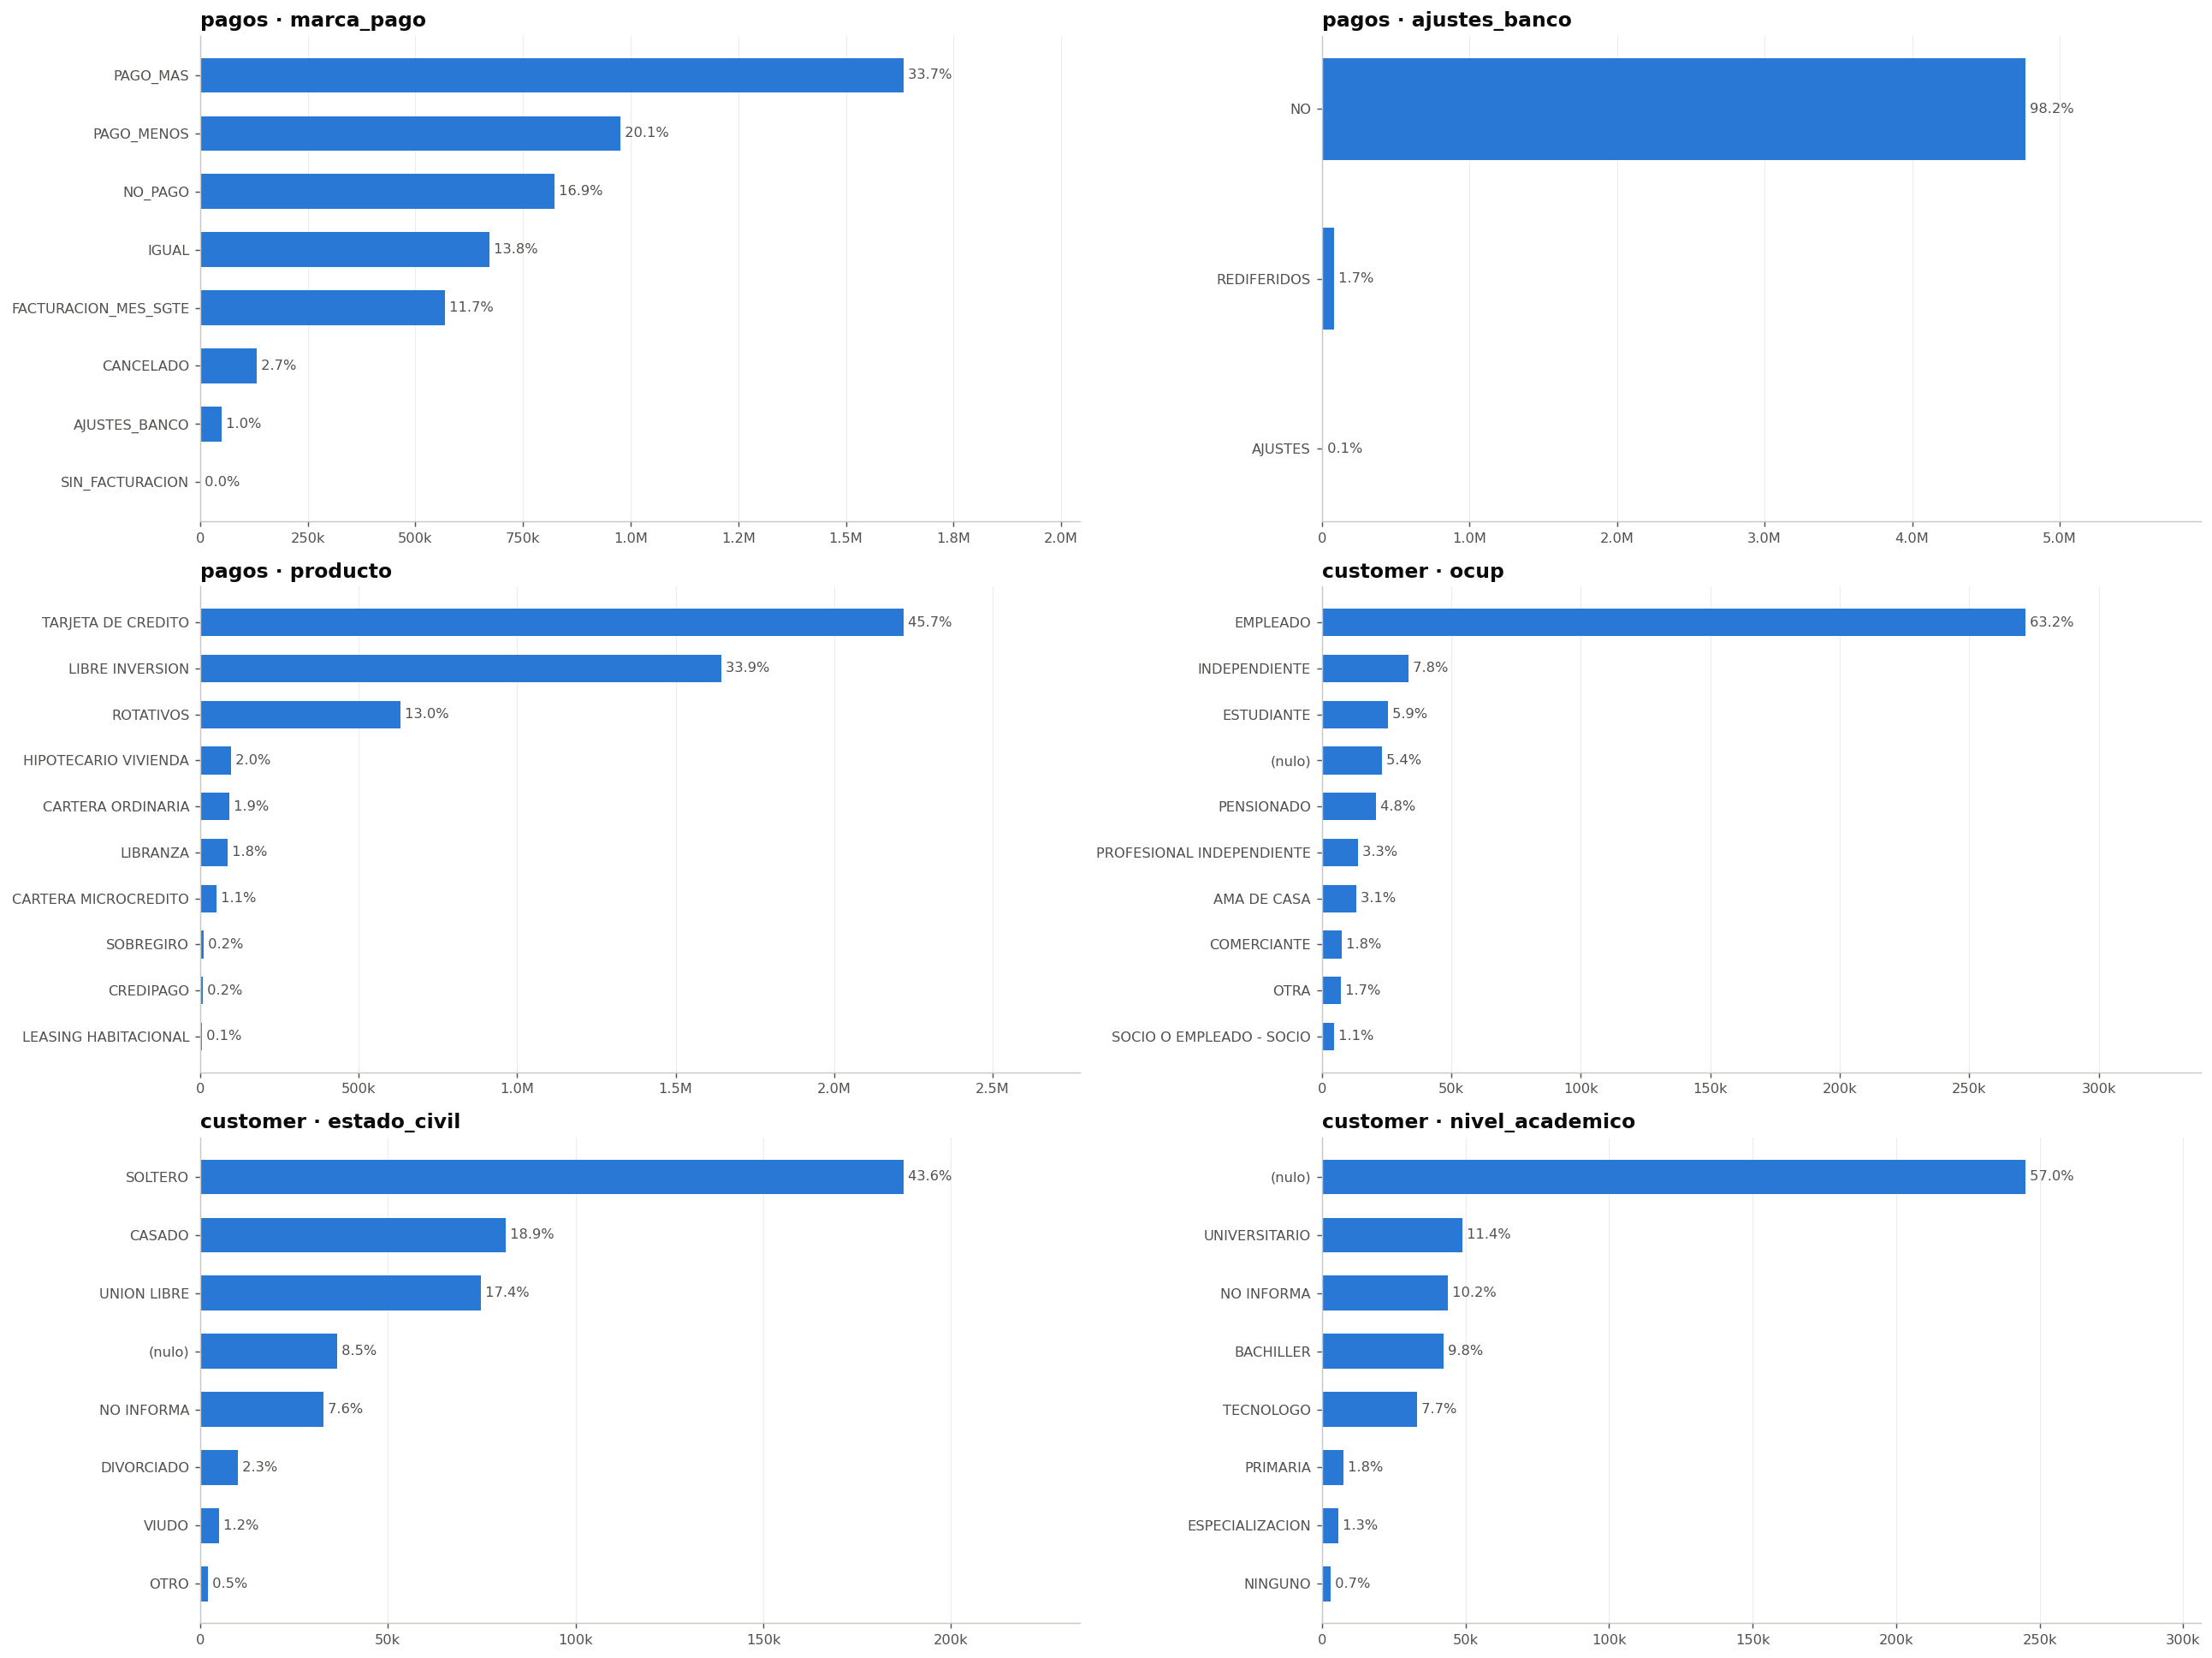

In [15]:
fig, ax = plt.subplots(3, 2, figsize=(20, 15)); ax = ax.ravel()
barh_freq(ax[0], pag.marca_pago, "pagos · marca_pago"); barh_freq(ax[1], pag.ajustes_banco, "pagos · ajustes_banco"); barh_freq(ax[2], pag.producto, "pagos · producto")
barh_freq(ax[3], cli.ocup, "customer · ocup"); barh_freq(ax[4], cli.estado_civil, "customer · estado_civil"); barh_freq(ax[5], cli.nivel_academico, "customer · nivel_academico")
plt.tight_layout(); plt.show()

**Lectura.** En pagos, un tercio de los meses tiene pago superior a la cuota (PAGO_MAS 34 %) y un 17 % sin pago; los ajustes del banco son raros (REDIFERIDOS 1,7 %) pero marcan a quien ya recibió un alivio. Tarjeta de crédito y libre inversión suman el 80 % de las obligaciones. En customer, el 63 % son empleados, el 44 % solteros, y nivel académico está vacío en el 57 %: la demografía es parcial y de calidad desigual.

## 9. Outliers

Dos paneles: porcentaje de valores fuera de Q1 − 3·IQR y Q3 + 3·IQR por variable, y cuántas veces el máximo supera al percentil 99,9 (tamaño de la cola extrema).

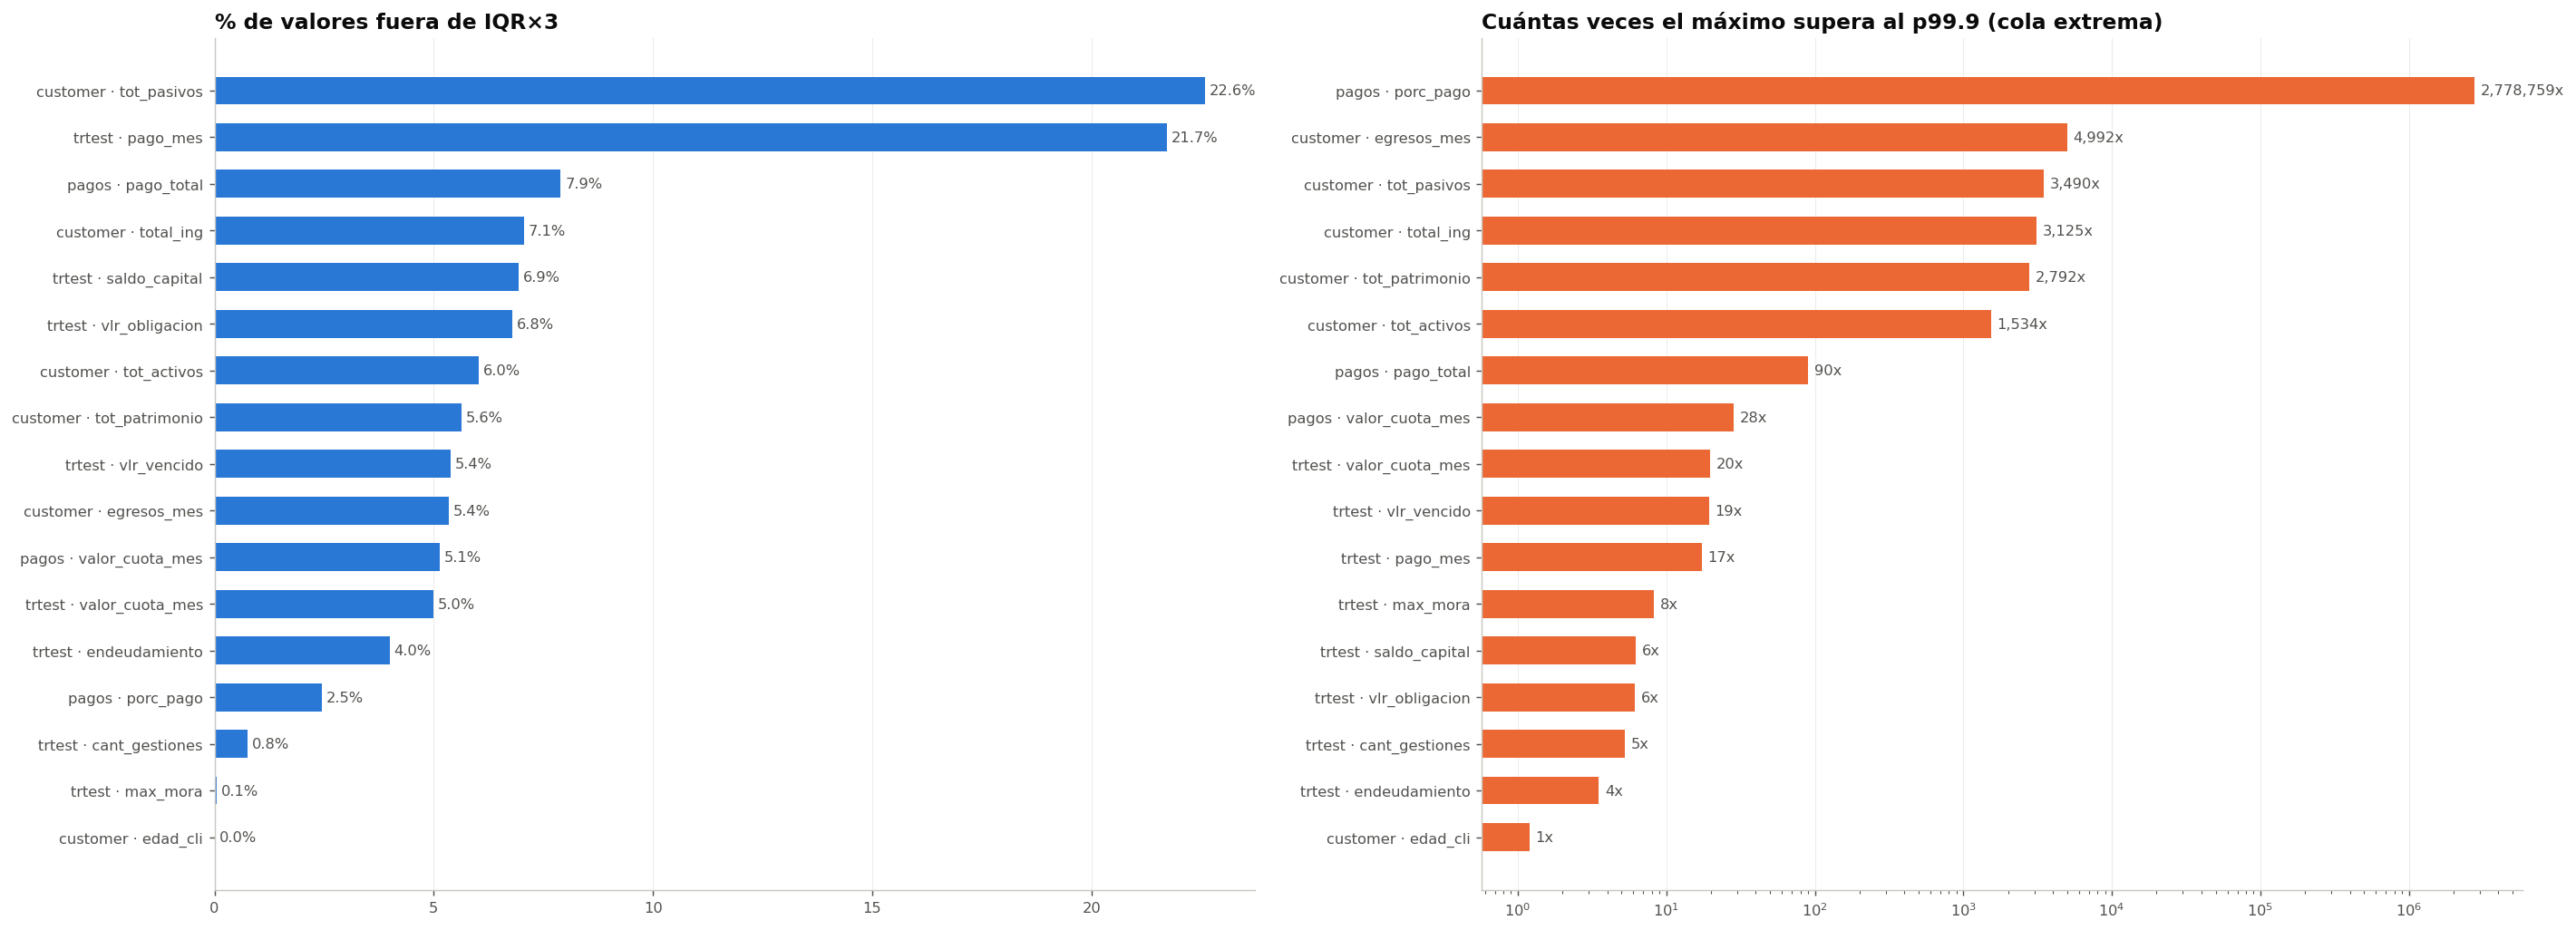

In [16]:
def pct_out(s):
    s = pd.to_numeric(s, errors="coerce").replace([np.inf, -np.inf], np.nan).dropna()
    q1, q3 = s.quantile([0.25, 0.75]); iqr = q3 - q1
    return ((s < q1 - 3 * iqr) | (s > q3 + 3 * iqr)).mean() * 100, s.max() / s.quantile(0.999)

vars_ = {"trtest": (tr, ["vlr_obligacion", "vlr_vencido", "saldo_capital", "endeudamiento", "valor_cuota_mes", "pago_mes", "max_mora", "cant_gestiones"]),
         "pagos": (pag, ["valor_cuota_mes", "pago_total", "porc_pago"]),
         "customer": (cli, ["edad_cli", "total_ing", "egresos_mes", "tot_activos", "tot_pasivos", "tot_patrimonio"])}
rows = [{"var": f"{k} · {c}", "% fuera IQR×3": pct_out(df[c])[0], "max / p99.9": pct_out(df[c])[1]} for k, (df, cols) in vars_.items() for c in cols]
o = pd.DataFrame(rows).set_index("var")

fig, axes = plt.subplots(1, 2, figsize=(22, 8))
d = o["% fuera IQR×3"].sort_values()
axes[0].barh(d.index, d.values, color=C_BLUE, height=0.6)
for y, v in zip(d.index, d.values): axes[0].text(v + 0.1, y, f"{v:.1f}%", va="center", fontsize=9, color=C_MUTED)
axes[0].set_title("% de valores fuera de IQR×3"); axes[0].grid(axis="y", visible=False)
d = o["max / p99.9"].sort_values()
axes[1].barh(d.index, d.values, color=C_ORANGE, height=0.6); axes[1].set_xscale("log")
for y, v in zip(d.index, d.values): axes[1].text(v * 1.1, y, f"{v:,.0f}x", va="center", fontsize=9, color=C_MUTED)
axes[1].set_title("Cuántas veces el máximo supera al p99.9 (cola extrema)"); axes[1].grid(axis="y", visible=False)
plt.tight_layout(); plt.show()

**Lectura.** `tot_pasivos` (23 %) y `pago_mes` (22 %) aparecen con muchos "outliers" porque la mayoría de sus valores son 0 y el rango intercuartílico colapsa: no son errores, son variables con masa en cero. Los montos tienen entre 4 % y 8 % de valores fuera de IQR×3, normal en distribuciones lognormales. La cola extrema es el problema real: en customer el máximo supera al p99,9 por factores de 1.500 a 5.000 (ingresos, activos, pasivos, egresos, patrimonio del orden de billones) y `porc_pago` por millones (cuota en cero). En `trtest` los máximos son razonables (4 a 20 veces el p99,9).

Boxplots en log10 de los montos de trtest, de cuota, pago y porcentaje de pago en pagos, y de las variables financieras de customer. Los puntos naranja son los valores fuera de los bigotes.

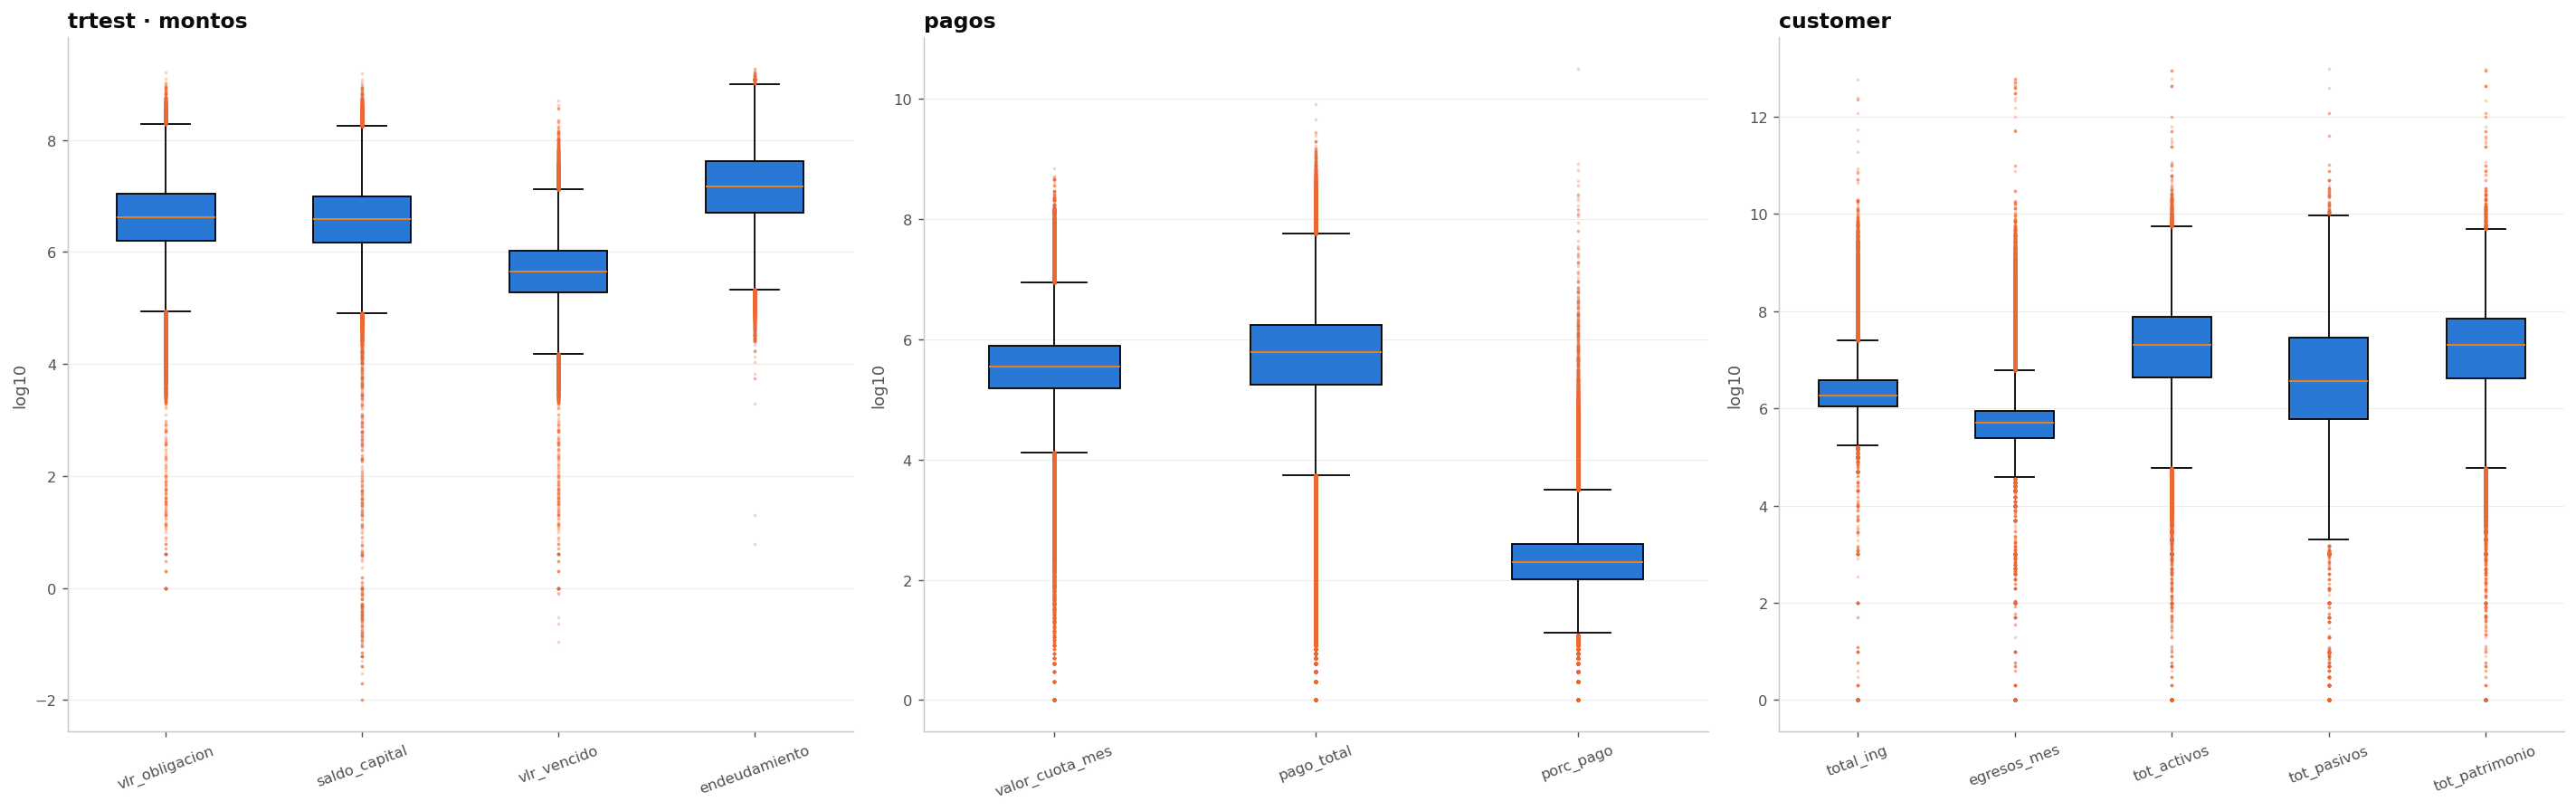

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(22, 7))
box_log(axes[0], {"vlr_obligacion": tr.vlr_obligacion, "saldo_capital": tr.saldo_capital, "vlr_vencido": tr.vlr_vencido, "endeudamiento": tr.endeudamiento}, "trtest · montos")
box_log(axes[1], {"valor_cuota_mes": pag.valor_cuota_mes, "pago_total": pag.pago_total, "porc_pago": pag.porc_pago}, "pagos")
box_log(axes[2], {"total_ing": cli.total_ing, "egresos_mes": cli.egresos_mes, "tot_activos": cli.tot_activos, "tot_pasivos": cli.tot_pasivos, "tot_patrimonio": cli.tot_patrimonio}, "customer")
plt.tight_layout(); plt.show()

**Lectura.** Los montos de `trtest` son compactos en escala log, con pocos puntos extremos. En pagos, `porc_pago` muestra la cola de valores absurdos por cuotas en cero. En customer todas las variables financieras tienen outliers superiores muy alejados de la caja: hay que acotar al p99 o aplicar logaritmo antes de modelar, y anular los valores que superan magnitudes plausibles.

Número de filas con valores imposibles o sospechosos según reglas de negocio, en escala log.

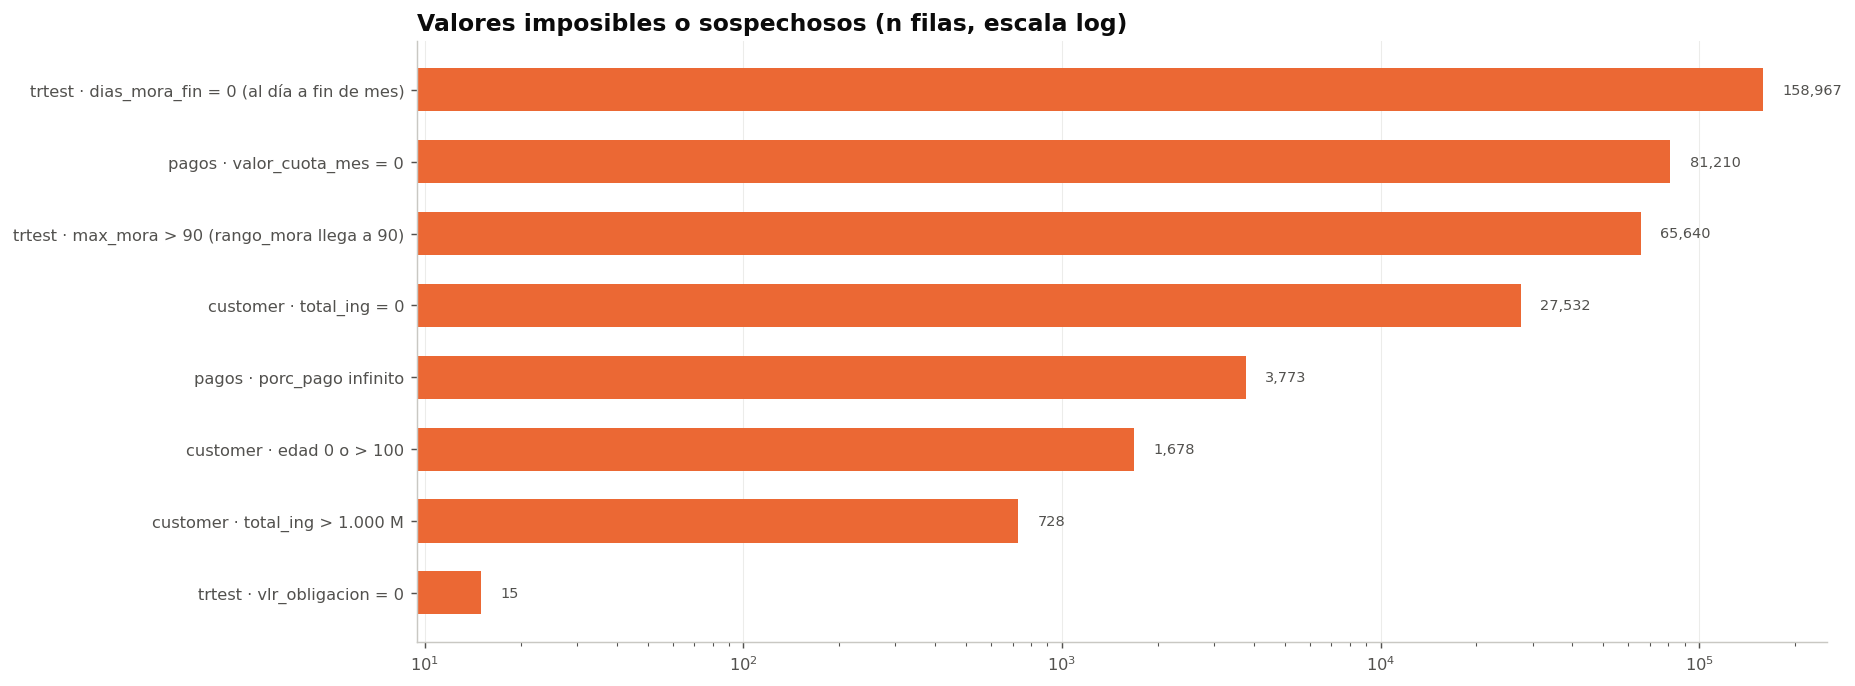

In [18]:
edad = pd.to_numeric(cli.edad_cli, errors="coerce"); ing = pd.to_numeric(cli.total_ing, errors="coerce")
imp = pd.Series({
    "customer · edad 0 o > 100": int(((edad == 0) | (edad > 100)).sum()),
    "customer · total_ing = 0": int((ing == 0).sum()),
    "customer · total_ing > 1.000 M": int((ing > 1e9).sum()),
    "pagos · porc_pago infinito": int(np.isinf(pag.porc_pago.fillna(0)).sum()),
    "pagos · valor_cuota_mes = 0": int((pag.valor_cuota_mes == 0).sum()),
    "trtest · vlr_obligacion = 0": int((tr.vlr_obligacion == 0).sum()),
    "trtest · max_mora > 90 (rango_mora llega a 90)": int((tr.max_mora > 90).sum()),
    "trtest · dias_mora_fin = 0 (al día a fin de mes)": int((tr.dias_mora_fin == 0).sum()),
}).sort_values()
fig, ax = plt.subplots(figsize=(14, 6))
ax.barh(imp.index, imp.values, color=C_ORANGE, height=0.6); ax.set_xscale("log")
for y, v in zip(imp.index, imp.values): ax.text(v * 1.15, y, f"{v:,}", va="center", fontsize=8, color=C_MUTED)
ax.set_title("Valores imposibles o sospechosos (n filas, escala log)"); ax.grid(axis="y", visible=False); plt.show()

**Lectura.** No todo lo listado es error. `dias_mora_fin = 0` (159 k) significa que la obligación se puso al día antes de cerrar el mes y `max_mora > 90` (66 k) indica que `rango_mora` se calcula sobre otra medida de mora: ambos son información, no defectos. Sí son errores o valores no informativos: cuota en cero (81 k, produce porcentajes infinitos), ingresos en cero (27,5 k), edades 0 o mayores a 100 (1.678), ingresos superiores a 1.000 millones (728) y obligaciones con valor cero (15). Tratamiento: nulo para los imposibles, acotar o log para las colas.

## 10. Selección de variables

Análisis sobre el dataset construido en el notebook 01 (`data/processed/train.parquet`, 133 variables con corte en t-1). Tres pasos: eliminación por criterio, varianza baja y correlación alta. La lista final se guarda en `data/processed/features_seleccionadas.csv`.

In [19]:
train = pd.read_parquet(ROOT / "data" / "processed" / "train.parquet")
ID_COLS = ["nit_enmascarado", "num_oblig_orig_enmascarado", "num_oblig_enmascarado", "fecha_var_rpta_alt", "ID", "t", "t_1"]
TARGET = "var_rpta_alt"
FEATS = [c for c in train.columns if c not in ID_COLS + [TARGET]]
nulos = train[FEATS].isna().mean().rename("nulos")
print(f"Variables en el dataset: {len(FEATS)}")

Variables en el dataset: 133


### 10.1 Eliminación por criterio

Variables que se retiran por una razón de negocio o de construcción, no por el modelo: nulos mayores al 50 %, casi constantes, redundancia con otra fuente de mayor cobertura, o valores crudos ya resumidos en otra variable.

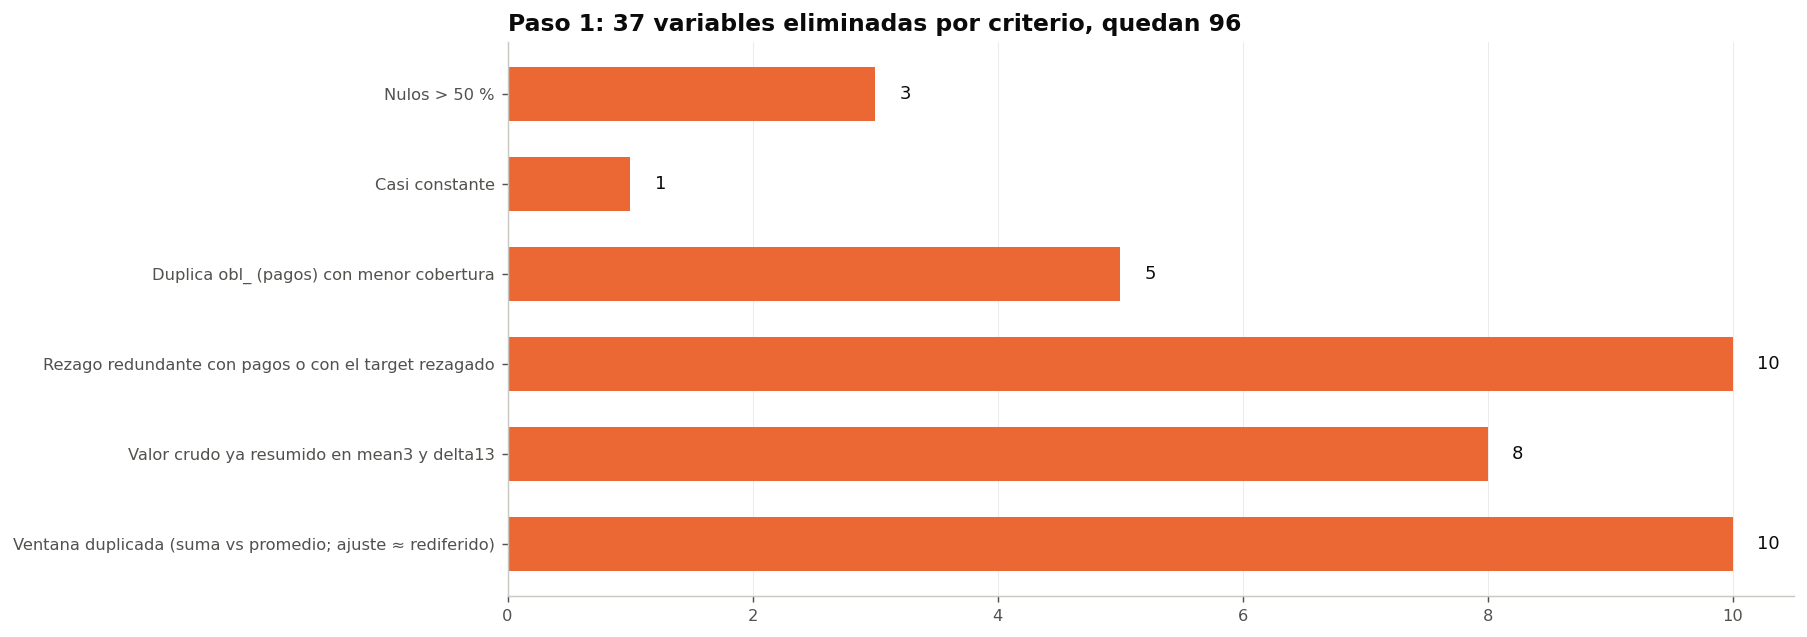

In [20]:
DROP = {
    "Nulos > 50 %": ["cli_tipo_vivienda", "cli_nivel_academico", "cli_nicho"],
    "Casi constante": ["cli_tipo_cli"],
    "Duplica obl_ (pagos) con menor cobertura": ["lag_producto_ult", "lag_producto_cons_ult", "lag_banca_ult", "lag_segmento_ult", "lag_aplicativo_ult"],
    "Rezago redundante con pagos o con el target rezagado": ["lag_rango_mora_ult", "lag_min_mora_ult", "lag_rpc_ult", "lag_promesas_cumplidas_ult", "lag_cant_acuerdo_ult",
        "lag_valor_cuota_mes_ult", "lag_pago_mes_ult", "lag_porc_pago_cuota_ult", "lag_marca_pago_ult", "lag_marca_alt_rank_ult"],
    "Valor crudo ya resumido en mean3 y delta13": ["prob_prob_propension_t2", "prob_prob_propension_t3", "prob_prob_alrt_temprana_t2", "prob_prob_alrt_temprana_t3",
        "prob_prob_auto_cura_t2", "prob_prob_auto_cura_t3", "prob_lote_t2", "prob_lote_t3"],
    "Ventana duplicada (suma vs promedio; ajuste ≈ rediferido)": ["pag_pago_total_sum_1m", "pag_pago_total_sum_3m", "pag_pago_total_sum_6m", "pag_pago_total_sum_12m",
        "pag_n_ajuste_1m", "pag_n_ajuste_3m", "pag_n_ajuste_6m", "pag_n_ajuste_12m", "pag_n_cancelado_1m", "pag_n_cancelado_3m"],
}
drop1 = sum(DROP.values(), []); faltan = [c for c in drop1 if c not in FEATS]; assert not faltan, faltan
keep1 = [c for c in FEATS if c not in drop1]

cnt = pd.Series({k: len(v) for k, v in DROP.items()})
fig, ax = plt.subplots(figsize=(14, 5))
ax.barh(cnt.index[::-1], cnt.values[::-1], color=C_ORANGE, height=0.6)
for yv, v in zip(cnt.index[::-1], cnt.values[::-1]): ax.text(v + 0.2, yv, str(v), va="center", fontsize=10)
ax.set_title(f"Paso 1: {len(drop1)} variables eliminadas por criterio, quedan {len(keep1)}"); ax.grid(axis="y", visible=False)
plt.tight_layout(); plt.show()

**Lectura.** Se retiran 37 variables y quedan 96. Los grupos más grandes son los rezagos redundantes de trtest (15), que ya están cubiertos por la tabla de pagos con cobertura total, y las ventanas y valores crudos duplicados (18).

### 10.2 Varianza baja

Para cada variable conservada, proporción de filas que tienen el valor más frecuente (sin contar nulos). Una variable donde un solo valor ocupa más del 99 % de las filas casi no aporta información. Se muestran las 25 más concentradas.

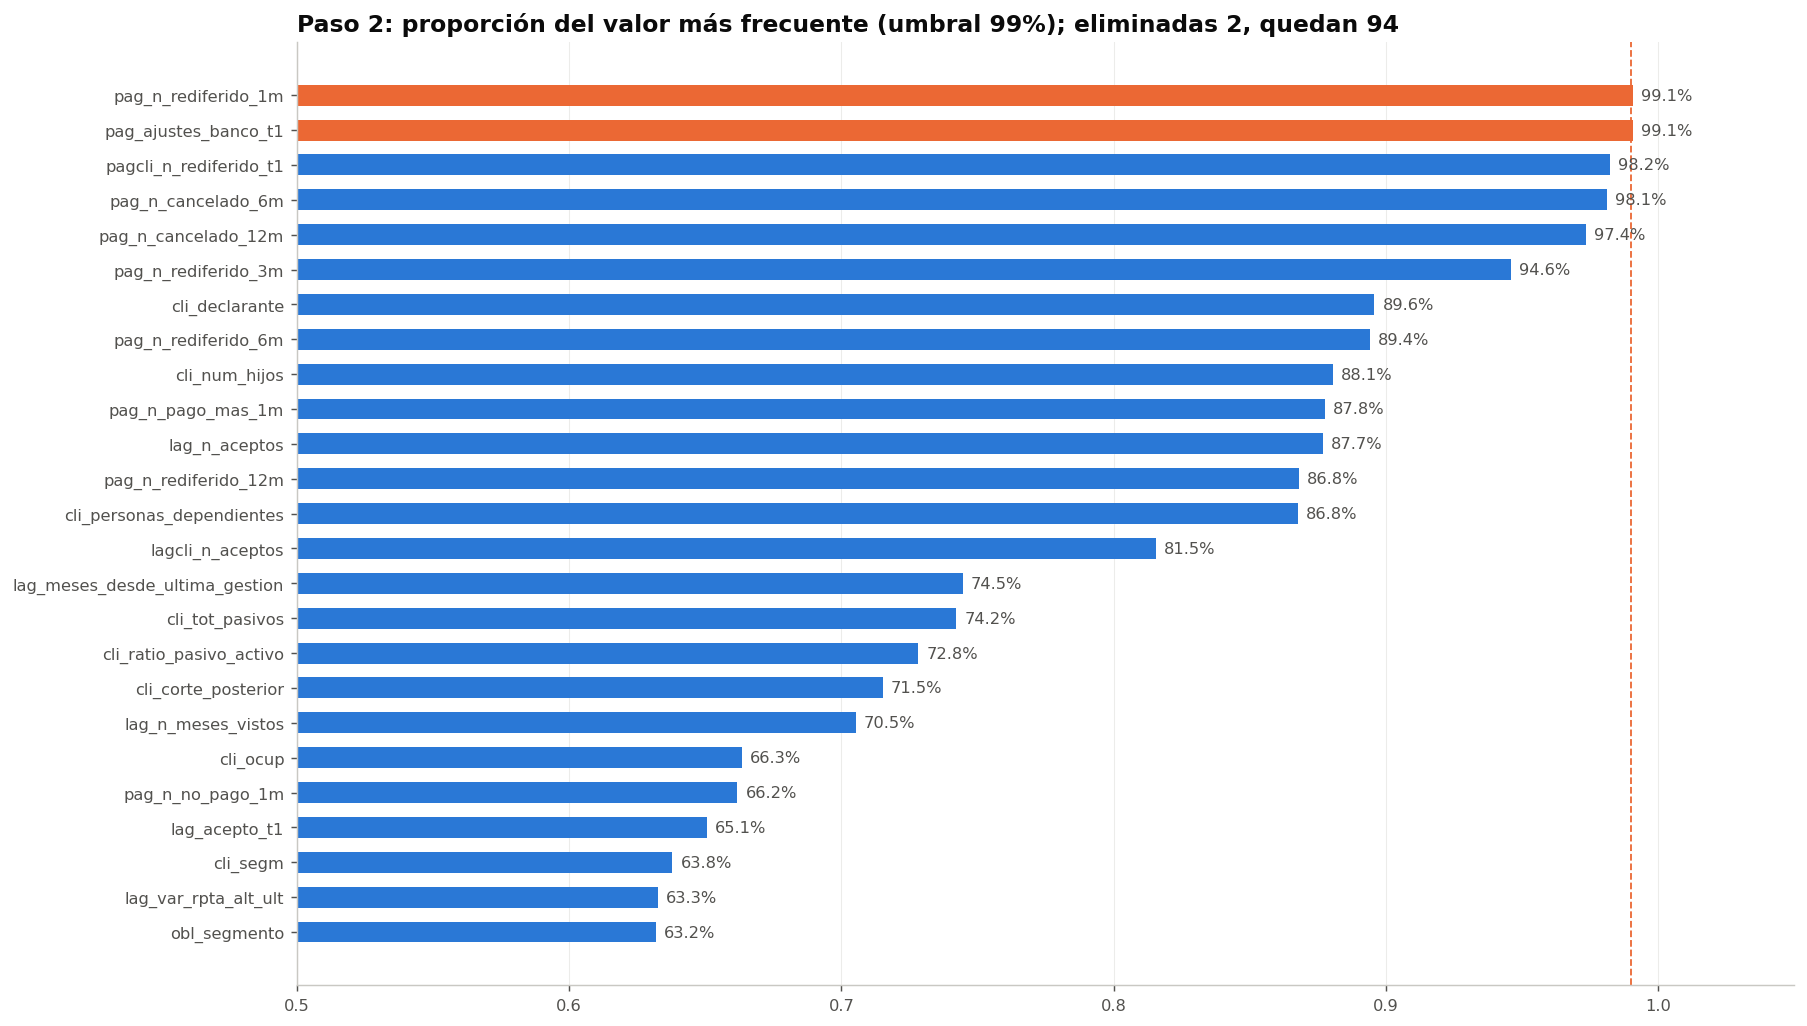

Eliminadas por varianza baja: ['pag_n_rediferido_1m', 'pag_ajustes_banco_t1']


In [21]:
def dominante(col):
    x = train[col].dropna()
    return x.value_counts(normalize=True).iloc[0] if len(x) else np.nan
dom = pd.Series({c: dominante(c) for c in keep1}, name="valor_dominante").sort_values(ascending=False)
UMBRAL_VAR = 0.99
drop2 = dom[dom > UMBRAL_VAR].index.tolist()
keep2 = [c for c in keep1 if c not in drop2]

d = dom.head(25).iloc[::-1]
fig, ax = plt.subplots(figsize=(14, 8))
ax.barh(d.index, d.values, color=[C_ORANGE if v > UMBRAL_VAR else C_BLUE for v in d.values], height=0.6)
for yv, v in zip(d.index, d.values): ax.text(v + 0.003, yv, f"{v:.1%}", va="center", fontsize=9, color=C_MUTED)
ax.axvline(UMBRAL_VAR, color=C_ORANGE, lw=1, ls="--"); ax.set_xlim(0.5, 1.05)
ax.set_title(f"Paso 2: proporción del valor más frecuente (umbral {UMBRAL_VAR:.0%}); eliminadas {len(drop2)}, quedan {len(keep2)}"); ax.grid(axis="y", visible=False)
plt.tight_layout(); plt.show()
print("Eliminadas por varianza baja:", drop2)

**Lectura.** Las variables más concentradas son los conteos de eventos raros: rediferidos y cancelaciones (el 0 domina) y la bandera de corte posterior de demografía. Las que superan el 99 % se retiran porque el modelo no puede aprender de un valor que casi nunca cambia. Las que están entre 90 % y 99 % se conservan: los pocos casos distintos son eventos de negocio relevantes (por ejemplo, ya recibió un alivio) y los modelos de árboles los aprovechan.

### 10.3 Correlación alta

Correlación de Spearman entre las variables numéricas conservadas, sobre una muestra de 150.000 filas. Se listan los pares con |r| ≥ 0,90. De cada par se conserva la variable con menos nulos (más cobertura en el test); si la cobertura es similar (diferencia menor a 2 puntos), se conserva la primera en el orden del dataset.

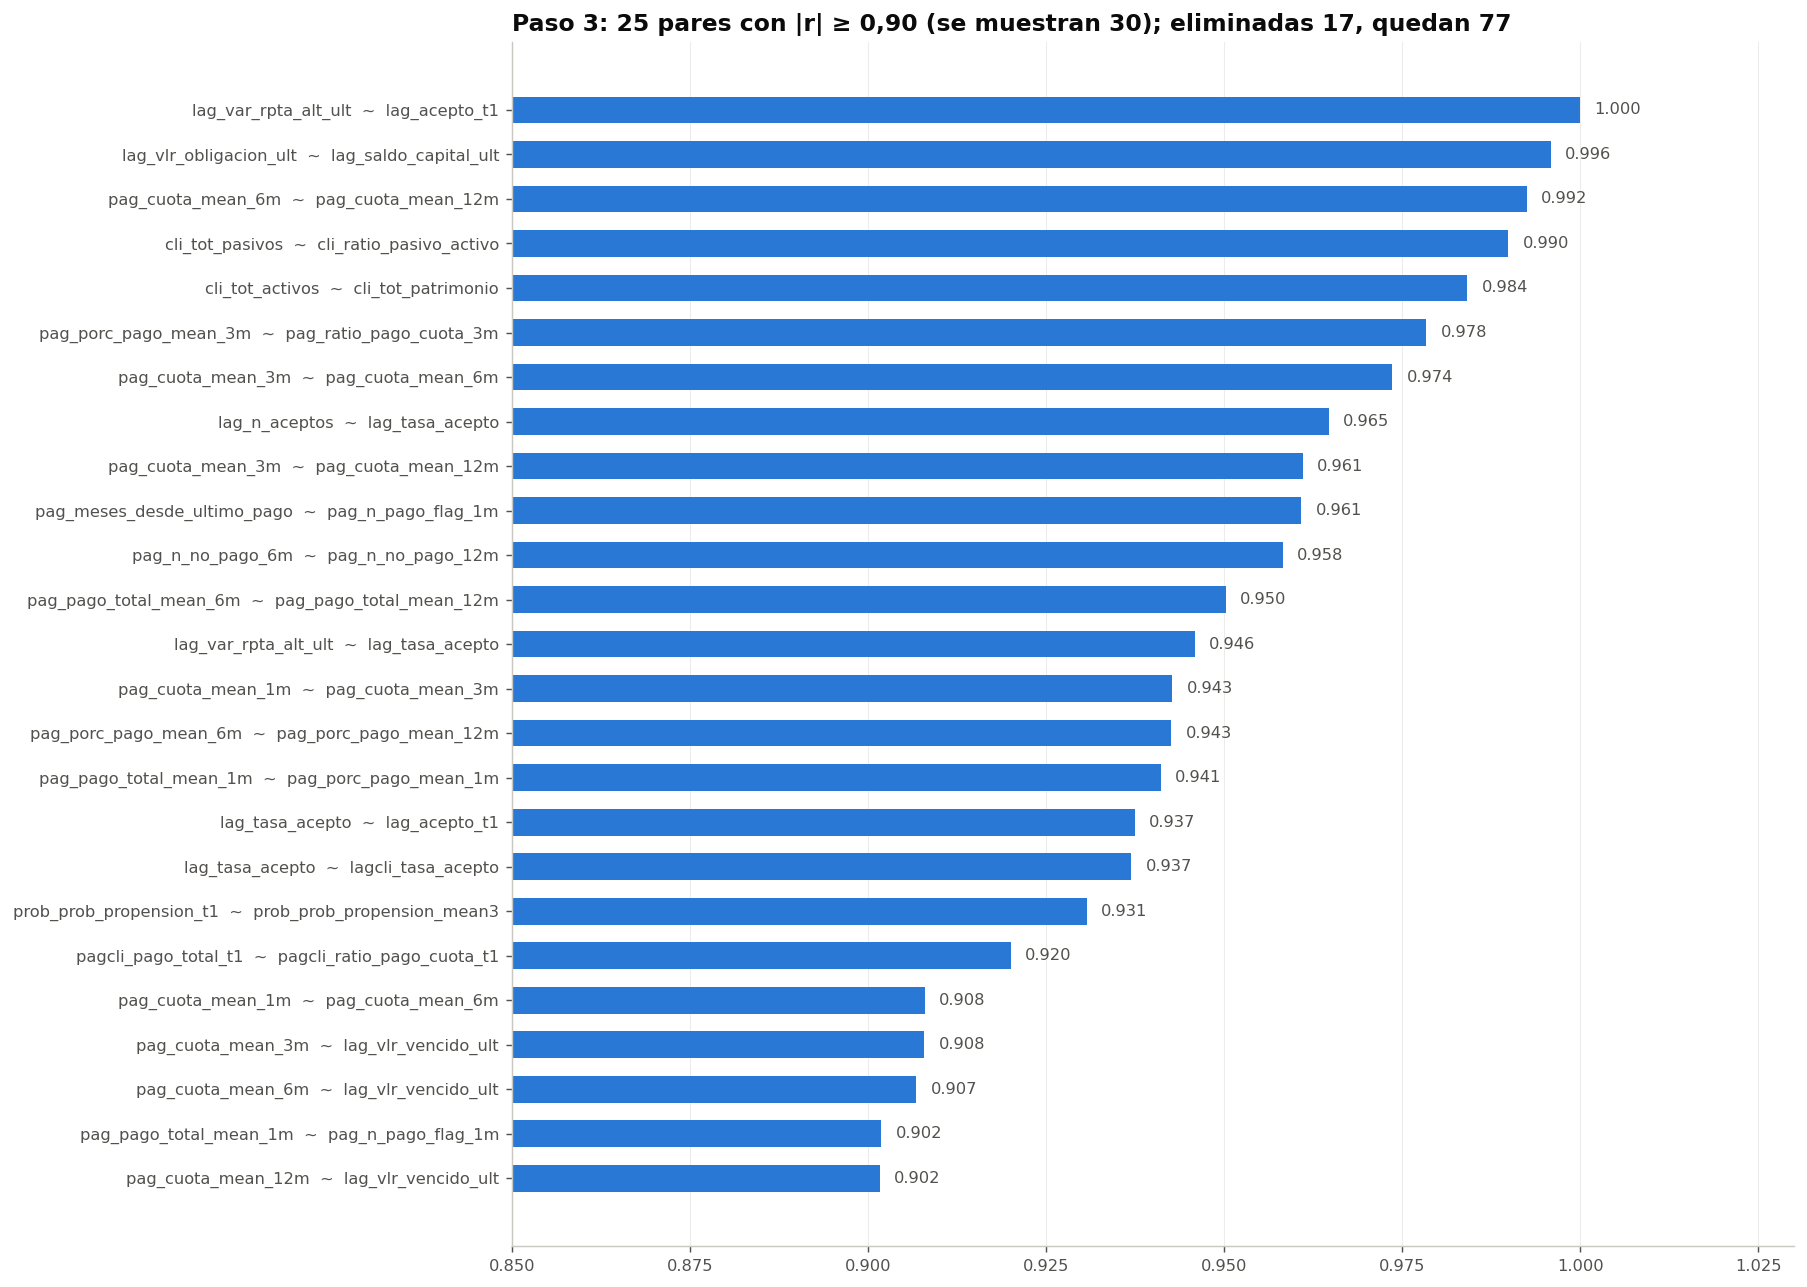

Eliminadas por correlación: ['lag_acepto_t1', 'lag_saldo_capital_ult', 'pag_cuota_mean_12m', 'cli_ratio_pasivo_activo', 'cli_tot_patrimonio', 'pag_ratio_pago_cuota_3m', 'pag_cuota_mean_6m', 'lag_tasa_acepto', 'pag_meses_desde_ultimo_pago', 'pag_n_no_pago_12m', 'pag_pago_total_mean_12m', 'pag_cuota_mean_3m', 'pag_porc_pago_mean_12m', 'pag_porc_pago_mean_1m', 'prob_prob_propension_mean3', 'pagcli_ratio_pago_cuota_t1', 'pag_n_pago_flag_1m']


In [22]:
num_cols = [c for c in keep2 if pd.api.types.is_numeric_dtype(train[c])]
samp = train[num_cols].sample(150_000, random_state=0)
corr = samp.corr(method="spearman")
pares = (corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack()
         .rename("r").reset_index().rename(columns={"level_0": "a", "level_1": "b"}))
pares["abs_r"] = pares.r.abs()
altos = pares[pares.abs_r >= 0.90].sort_values("abs_r", ascending=False).reset_index(drop=True)

# Eliminación greedy: en cada par se descarta la de más nulos; si la cobertura es similar, la segunda del par
def peor(a, b):
    if abs(nulos[a] - nulos[b]) > 0.02:
        return a if nulos[a] > nulos[b] else b
    return b
drop3 = []
for _, row in altos.iterrows():
    a, b = row.a, row.b
    if a in drop3 or b in drop3: continue
    drop3.append(peor(a, b))
keep3 = [c for c in keep2 if c not in drop3]

d = altos.head(30).iloc[::-1]
fig, ax = plt.subplots(figsize=(14, 10))
ax.barh([f"{a}  ~  {b}" for a, b in zip(d.a, d.b)], d.abs_r, color=C_BLUE, height=0.6)
for i, v in enumerate(d.abs_r): ax.text(v + 0.002, i, f"{v:.3f}", va="center", fontsize=9, color=C_MUTED)
ax.set_xlim(0.85, 1.03); ax.set_title(f"Paso 3: {len(altos)} pares con |r| ≥ 0,90 (se muestran 30); eliminadas {len(drop3)}, quedan {len(keep3)}"); ax.grid(axis="y", visible=False)
plt.tight_layout(); plt.show()
print("Eliminadas por correlación:", drop3)

**Lectura.** Las correlaciones altas están dentro de una misma familia: ventanas consecutivas de la misma medida (promedio de cuota a 3, 6 y 12 meses), el score en t-1 frente a su promedio de 3 meses, activos frente a patrimonio, y las distintas formas de resumir la aceptación previa de la obligación. Son duplicados de información, no señales distintas. Con árboles la correlación no daña la predicción, pero sí reparte la importancia entre copias y dificulta explicar el modelo.

### 10.4 Lista final

Resumen de los tres pasos y guardado de la lista de variables seleccionadas.

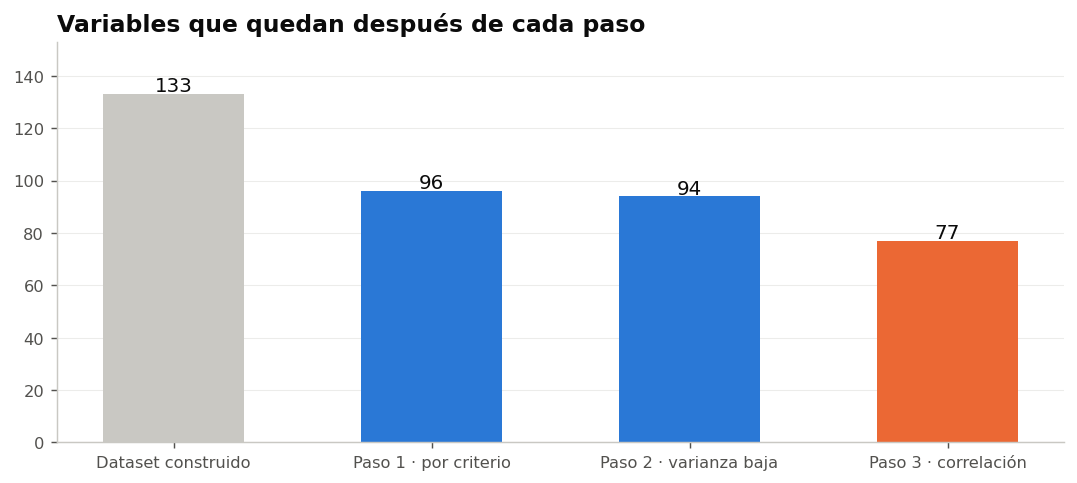

Guardadas 77 variables en data/processed/features_seleccionadas.csv
bloque  cli  lag  lagcli  obl  pag  pagcli  prob
n        19   14       3    3   24       5     9


In [23]:
resumen = pd.Series({"Dataset construido": len(FEATS), "Paso 1 · por criterio": len(keep1), "Paso 2 · varianza baja": len(keep2), "Paso 3 · correlación": len(keep3)})
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(resumen.index, resumen.values, color=[C_GRAY, C_BLUE, C_BLUE, C_ORANGE], width=0.55)
for i, v in enumerate(resumen.values): ax.text(i, v + 1, str(v), ha="center", fontsize=11)
ax.set_ylim(0, resumen.max() * 1.15); ax.set_title("Variables que quedan después de cada paso"); ax.grid(axis="x", visible=False)
plt.show()

sel = pd.DataFrame({"feature": keep3, "bloque": [c.split("_")[0] for c in keep3], "nulos": nulos[keep3].values})
sel.to_csv(ROOT / "data" / "processed" / "features_seleccionadas.csv", index=False)
print(f"Guardadas {len(keep3)} variables en data/processed/features_seleccionadas.csv")
print(sel.groupby("bloque").size().rename("n").to_frame().T.to_string())

**Lectura.** De 133 variables quedan las de la lista final: base de scores del banco y pagos (cobertura total), demografía reducida y un historial de aceptación resumido. La selección se hizo con criterios que no miran el resultado del modelo, así que no hay sobreajuste en este paso. En el notebook de modelado se comparará el F1 en diciembre con las 133 y con la lista final para confirmar que la reducción no cuesta desempeño, y la importancia del modelo servirá para una segunda poda.

## 11. Hallazgos

- **Etiqueta** balanceada (48 % de unos), estable por mes. Fuerte persistencia: quien aceptó en t-1 acepta el 65 % en t.
- **Cobertura**: probabilidades y pagos cubren >99 % de train y test; demografía el 80 %. El 49 % de las obligaciones del test ya están en train.
- **Fuga**: las columnas de trtest describen el resultado del mismo mes y no existen en el test. Solo sirven rezagadas.
- **Nulos**: `None` como texto; estructurales en opciones 2/3 y alternativa aplicada; vivienda, nivel académico y nicho > 50 % en customer.
- **Duplicados**: solo llaves repetidas menores (3, 28, 1) en auxiliares; los de trtest son IDs distintos.
- **Outliers**: montos con máximos de 10 a 1.000 veces el p99.9; `porc_pago` infinito; edades 0 o > 100. Tratar con log, acotar y anular imposibles.
- **Selección**: de 133 variables del dataset construido se retiran las redundantes, casi constantes y muy correlacionadas con criterios previos al modelo; la lista final queda en `features_seleccionadas.csv`.
- **Para el modelo**: variables con corte en t-1, validación temporal (train 08-11, valid 12), umbral optimizado para F1.